# 01 - LV Scar Exploration

Focus: Core Zone (CZ) only.

Pipeline:
1. Scan + EDA
2. 80/20 split
3. 3-D visualisation (aligned overlay + grid)
4. 2-D polar maps + superposition
5. ISOMAP shape analysis

## 0 - Imports & config

In [1]:
import json, random, sys
from dataclasses import dataclass, field
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from data_loading import scan, diagnose, PatientCase
import pandas as pd

HD_ROOT          = r"F:/RM_TEKNON_DEVELOP"
SEED             = 42
TRAIN_RATIO      = 0.80
N_R              = 64
N_THETA          = 128
GRID3D_MAX       = 24
ISOMAP_PTS       = 800
ISOMAP_K         = 10
MIN_VERTS_FRAGMENT = 30
MIN_VERTS_ISOMAP = 5
MAX_PLOT_FRAGMENTS = 4

                        # False: only real CZ cases

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
OUT = RESULTS / "01_scar_exploration"
OUT.mkdir(parents=True, exist_ok=True)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120


## 1 - Scan & EDA

In [2]:
all_cases = scan(HD_ROOT)

def has_cz(c):
    p = c.tissue_surfaces.get("core")
    return p is not None and p.exists()

valid = [c for c in all_cases if has_cz(c)]

print(f"Total scanned : {len(all_cases)}")
print(f"With real CZ  : {len(valid)}")


Total scanned : 168
With real CZ  : 105


### 1a - EDA: dataset overview

In [3]:
c1,c2,c3,c4 = "Year","Total","Has LV","Has CZ"
print(f"{c1:<6} {c2:>7} {c3:>8} {c4:>8}")
print("-" * 33)
for year in sorted(set(c.year for c in all_cases)):
    yc   = [c for c in all_cases if c.year == year]
    n_lv = sum(1 for c in yc if c.lv_dir is not None)
    n_cz = sum(1 for c in yc if has_cz(c))
    print(f"{year:<6} {len(yc):>7} {n_lv:>8} {n_cz:>8}")
print("-" * 33)
tot = "TOTAL"
print(f"{tot:<6} {len(all_cases):>7} {sum(1 for c in all_cases if c.lv_dir is not None):>8} {sum(1 for c in all_cases if has_cz(c)):>8}")


Year     Total   Has LV   Has CZ
---------------------------------
2021        48       12       12
2022        27       23       23
2023        47       45       32
2024        31       31       31
2025        15        7        7
---------------------------------
TOTAL      168      118      105


### 1b - EDA: why cases are missing LV or CZ

For each case without LV dir or without CZ, diagnose the root cause:
- **No Basal/Data path**: the DE-MRI folder structure is absent entirely
- **No LV folder**: DE-MRI folder exists but LV subfolder missing
- **No TISSUE folder**: LV found but TISSUE subfolder absent
- **No CZ file**: TISSUE exists but no file matches Core Zone patterns
- **CZ file empty**: file found but 0 bytes on disk


In [4]:
from pathlib import Path

_DE_MRI_VARIANTS = ("DE-MRI", "DE-MRI 3D", "DE-MRI 2D")

def _diagnose_case(c):
    """Return a short string explaining why a case is missing LV or CZ."""
    base = Path(c.root) / "Basal" / "Data"
    if not base.exists():
        return "no Basal/Data path"
    variants_found = [v for v in _DE_MRI_VARIANTS if (base / v).exists()]
    if not variants_found:
        tried = ", ".join(_DE_MRI_VARIANTS)
        return f"no DE-MRI folder (tried: {tried})"
    if c.lv_dir is None:
        return f"DE-MRI found ({variants_found[0]}) but no LV subfolder"
    tissue = c.lv_dir / "TISSUE"
    if not tissue.exists():
        return "no TISSUE folder"
    vtks = list(tissue.rglob("*.vtk"))
    if not vtks:
        return "TISSUE exists but no VTK files"
    core = c.tissue_surfaces.get("core")
    if core is None:
        names = [f.name for f in vtks[:8]]
        return f"no CZ match in TISSUE (files: {names})"
    if core.stat().st_size == 0:
        return "CZ file is empty (0 bytes)"
    return "ok"

# Cases missing LV
no_lv = [c for c in all_cases if c.lv_dir is None]
print(f"Cases without LV dir: {len(no_lv)}")
if no_lv:
    from collections import Counter
    reasons = Counter(_diagnose_case(c) for c in no_lv)
    for reason, count in reasons.most_common():
        print(f"  {count:>3}x  {reason}")

print()

# Cases with LV but no CZ
no_cz = [c for c in all_cases if c.lv_dir is not None and not has_cz(c)]
print(f"Cases with LV but no CZ: {len(no_cz)}")
if no_cz:
    from collections import Counter
    reasons = Counter(_diagnose_case(c) for c in no_cz)
    for reason, count in reasons.most_common():
        print(f"  {count:>3}x  {reason}")


Cases without LV dir: 50
   35x  no DE-MRI folder (tried: DE-MRI, DE-MRI 3D, DE-MRI 2D)
   15x  no Basal/Data path

Cases with LV but no CZ: 13
   12x  TISSUE exists but no VTK files
    1x  no CZ match in TISSUE (files: ['3D Corridor 3D Border Zone.vtk', '3D Corridor Border Zone on Layer.vtk', '3D Corridor Centerlines.vtk', '3D Corridor Filtered Centerlines.vtk', '3D Corridor Labels.vtk', '3D Corridor Unified Centerlines Tubes.vtk', '3D Corridor Unified Centerlines.vtk', 'Automatic 3D Corridors.vtk'])


## 2 - 80/20 split

In [5]:
random.seed(SEED)
shuffled = random.sample(valid, len(valid))
n_known  = int(len(shuffled) * TRAIN_RATIO)
known    = shuffled[:n_known]
held_out = shuffled[n_known:]

(RESULTS / "split.json").write_text(json.dumps({
    "seed": SEED, "train_ratio": TRAIN_RATIO,
    "known":    [f"{c.year}/{c.patient_id}" for c in known],
    "held_out": [f"{c.year}/{c.patient_id}" for c in held_out],
}, indent=2))
print(f"Known: {len(known)}   Held-out: {len(held_out)}")


Known: 84   Held-out: 21


## 3 - 3-D visualisation

Each render: Left Ventricle shell (semi-transparent) + CZ (opaque red).

For the overlay all LV meshes are aligned before stacking:
- apex translated to origin
- long axis rotated to Z (all hearts point the same way)

This makes the population view meaningful: you can see which LV regions tend to carry CZ scar.

In [6]:
def _best_shell(case):
    """Left Ventricle > Myocardium > Endo > Epi."""
    for key in ("lv", "myocardium", "endo", "epi"):
        p = case.anatomy.get(key)
        if p is not None and p.exists():
            return pv.read(str(p))
    return None


def _compute_transform(lv_mesh):
    """Returns (R, apex) so that (pts - apex) @ R.T puts apex at origin, long axis along +Z."""
    pts    = np.array(lv_mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    z  = np.array([0., 0., 1.])
    v  = np.cross(axis, z)
    s  = np.linalg.norm(v)
    c  = np.dot(axis, z)
    if s < 1e-9:
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R  = np.eye(3) + vx + vx @ vx * ((1 - c) / (s ** 2))
    return R, apex


def _apply_transform(mesh, R, apex):
    m = mesh.copy()
    m.points = (np.array(mesh.points) - apex) @ R.T
    return m


def get_cz_mesh(case):
    """Load the real core-zone scar mesh for one case.

    Older notebook iterations supported proxy meshes, but this version only
    uses real CZ surfaces discovered by data_loading.scan().
    """
    p = case.tissue_surfaces.get('core')
    if p is None or not p.exists():
        return None
    return pv.read(str(p))

print("3-D helpers ready.")


3-D helpers ready.


### 3b - Per-patient 3-D grid (first GRID3D_MAX cases)

3-D grid: 100%|██████████| 84/84 [00:38<00:00,  2.17it/s]


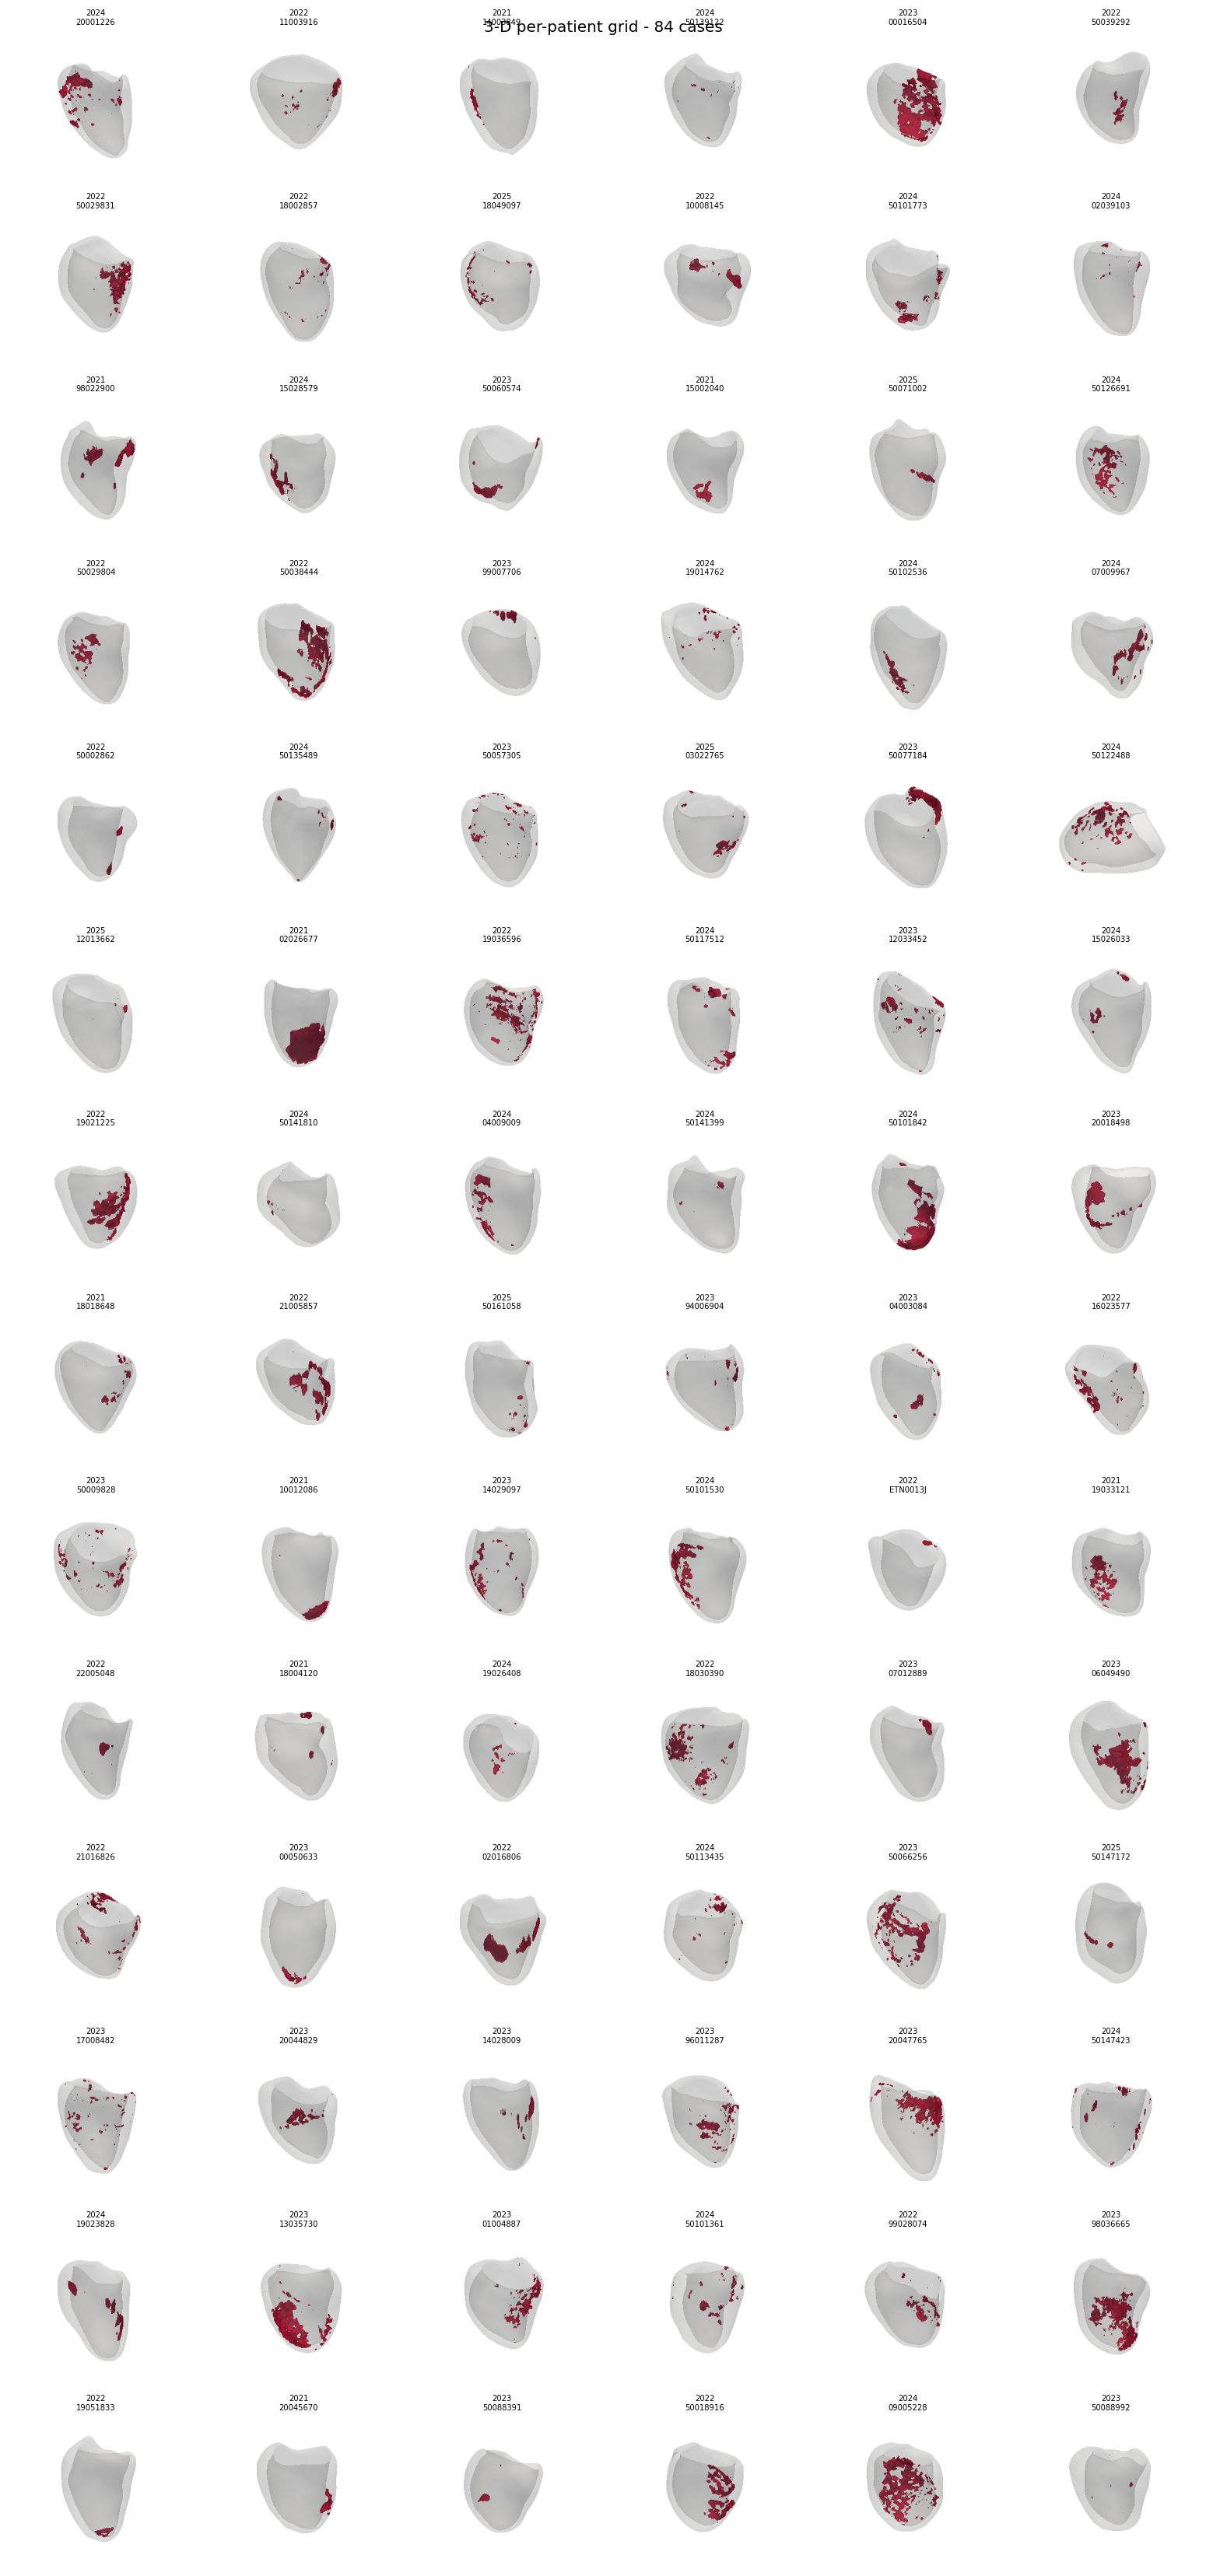

In [7]:
subset   = known
ncols_3d = 6
nrows_3d = int(np.ceil(len(subset) / ncols_3d))

thumbnails = []
for case in tqdm(subset, desc='3-D grid'):
    try:
        cz = get_cz_mesh(case)
        if cz is None:
            continue
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background('white')
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='#cccccc', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color='crimson', opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        thumbnails.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f'  skip {case.year}/{case.patient_id}: {e}')

fig, axes = plt.subplots(nrows_3d, ncols_3d,
                         figsize=(ncols_3d * 2.2, nrows_3d * 2),
                         squeeze=False)
fig.suptitle(f'3-D per-patient grid - {len(thumbnails)} cases',
             fontsize=12)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis('off')
for ax, (case, img) in zip(axes_flat, thumbnails):
    ax.imshow(img)
    ax.set_title(f'{case.year}\n{case.patient_id}', fontsize=6)
plt.tight_layout()
plt.savefig(OUT / '3d_grid_known.png', bbox_inches='tight')
plt.show()


## 4 - 2-D cylindrical polar projection

How it works:
1. PCA on the LV shell finds the long axis (apex to base).
2. **PCA on the basal ring** is the default way to fix theta=0.
   The LV cross-section at basal level has two concavities where the RV
   attaches (septal dents). PC1 captures the insertion axis globally, then
   the concave half-axis is chosen as the septal reference. The older dip
   detector is kept only as a diagnostic comparison method.
3. Each CZ vertex gets r (0=apex, 1=base) and theta (0-360 from reference).
4. Rasterise onto an (N_R x N_THETA) binary grid.
5. Bull's-eye: apex at centre, base at outer ring, with an overlaid
   approximate AHA 17-segment reference so the anatomical sections are visible.

### How PCA solves the rotation problem

**The problem**: each patient's LV is scanned in a slightly different
orientation, so the circumferential angle theta=0 of one patient's polar map
points in a different anatomical direction than another patient's theta=0.
Stacking polar maps without correction smears scar from different anatomical
regions on top of each other.

**The PCA solution** ():
1. Extract points on the basal ring (60-85% along the long axis).
2. Project them onto the plane perpendicular to the long axis (2-D ring).
3. Run SVD/PCA on the 2-D ring: PC1 is the axis of maximum variance, which
   aligns with the two RV insertion concavities because they are the dominant
   shape asymmetry of that cross-section.
4. To disambiguate the two ends of PC1, compare the mean radius on each side.
   The septal half has smaller mean radius (concave) so it is assigned theta=0.
5. All theta values are measured from this anatomically consistent reference.

This is robust to scan orientation and to >2 dips from segmentation artefacts
because it uses the global shape of the ring rather than individual peak depths.
The older dip detector (Method A) is still computed for comparison in section 4d.

Important: this projection uses the LV **long axis** (apex to base), not a short-axis slice.
The short-axis information is only used locally when measuring the circumferential angle in
planes perpendicular to that long axis.

Known limitation: apex is a dome so apical scars spread over the inner disc.
Use ISOMAP (Section 5) for faithful shape analysis.


In [8]:
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec

def _long_axis(mesh):
    pts    = np.array(mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    return axis, apex


def _plane_basis(axis):
    sec = np.array([0., 0., 1.])
    if abs(np.dot(axis, sec)) > 0.9:
        sec = np.array([1., 0., 0.])
    u = np.cross(axis, sec); u /= np.linalg.norm(u)
    w = np.cross(axis, u)
    return u, w


def _rv_reference(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Method A - dip detection: direction toward midpoint of 2 deepest radial dips.

    The two deepest concavities in the basal ring correspond to the RV attachment
    points. Falls back to an arbitrary stable direction when fewer than 2 dips
    are found. Sensitive to manual segmentation artefacts that introduce extra dips.
    """
    u, w  = _plane_basis(axis)
    pts   = np.array(lv_mesh.points)
    proj  = (pts - apex) @ axis
    span  = proj.max() - proj.min()
    mask  = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring  = pts[mask]
    if len(ring) < 20:
        return u
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    angles   = np.arctan2(diff[:, 1], diff[:, 0])
    radii    = np.linalg.norm(diff, axis=1)
    idx      = np.argsort(angles)
    smooth_r = uniform_filter1d(radii[idx], size=max(3, len(radii)//20), mode='wrap')
    peaks, _ = find_peaks(-smooth_r, distance=max(5, len(smooth_r)//8))
    if len(peaks) < 2:
        return u
    top2     = peaks[np.argsort(-smooth_r[peaks])[:2]]
    ins_ang  = np.arctan2(diff[idx[top2], 1], diff[idx[top2], 0])
    mid_2d   = np.array([np.cos(ins_ang).mean(), np.sin(ins_ang).mean()])
    norm     = np.linalg.norm(mid_2d)
    if norm < 1e-9:
        return u
    return (mid_2d[0] * u + mid_2d[1] * w) / norm


def _rv_reference_pca(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Method B - PCA on basal ring shape: direction toward the concave (septal) side.

    PC1 of the 2-D basal cross-section is the axis of maximum variance, which
    passes through the two RV insertion concavities. Disambiguate which half-axis
    points toward the septum by comparing the mean radius of each half: the septal
    side has smaller mean radius (concavity). Robust to >2 dips from segmentation
    artefacts because it uses all ring points globally rather than peak depths.
    """
    u, w = _plane_basis(axis)
    pts  = np.array(lv_mesh.points)
    proj = (pts - apex) @ axis
    span = proj.max() - proj.min()
    mask = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring = pts[mask]
    if len(ring) < 20:
        return u
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    _, _, Vt = np.linalg.svd(diff, full_matrices=False)
    pc1      = Vt[0]                           # axis of max variance through insertions
    proj_pc1 = diff @ pc1
    mask_pos = proj_pc1 > 0
    mask_neg = proj_pc1 < 0
    r_pos = np.linalg.norm(diff[mask_pos], axis=1).mean() if mask_pos.any() else np.inf
    r_neg = np.linalg.norm(diff[mask_neg], axis=1).mean() if mask_neg.any() else np.inf
    sign  = -1.0 if r_pos < r_neg else 1.0    # septal side = smaller mean radius
    direction = sign * pc1
    return direction[0] * u + direction[1] * w


_AHA_RING_RADII = (0.25, 0.50, 0.75)
_AHA_BASAL_MID_BOUNDS_DEG = (30, 90, 150, 210, 270, 330)
_AHA_APICAL_BOUNDS_DEG = (45, 135, 225, 315)
_AHA_SEGMENT_LABELS = (
    (1,   0, 0.875), (2, 300, 0.875), (3, 240, 0.875),
    (4, 180, 0.875), (5, 120, 0.875), (6,  60, 0.875),
    (7,   0, 0.625), (8, 300, 0.625), (9, 240, 0.625),
    (10, 180, 0.625), (11, 120, 0.625), (12,  60, 0.625),
    (13,   0, 0.375), (14, 270, 0.375), (15, 180, 0.375), (16,  90, 0.375),
    (17,   0, 0.125),
)


def _theta_deg(deg):
    return np.deg2rad(deg % 360)


def _overlay_aha_segments(ax, label_segments=True, linecolor='#222222', linewidth=0.8):
    theta = np.linspace(0, 2*np.pi, 361)
    for radius in _AHA_RING_RADII:
        ax.plot(theta, np.full_like(theta, radius), color=linecolor, lw=linewidth, alpha=0.85)
    for deg in _AHA_BASAL_MID_BOUNDS_DEG:
        th = _theta_deg(deg)
        ax.plot([th, th], [_AHA_RING_RADII[1], 1.0], color=linecolor, lw=linewidth, alpha=0.85)
    for deg in _AHA_APICAL_BOUNDS_DEG:
        th = _theta_deg(deg)
        ax.plot([th, th], [0.0, _AHA_RING_RADII[1]], color=linecolor, lw=linewidth, alpha=0.85)
    if label_segments:
        for seg, deg, radius in _AHA_SEGMENT_LABELS:
            ax.text(_theta_deg(deg), radius, str(seg), fontsize=7, ha='center', va='center',
                    color='black', zorder=5,
                    bbox=dict(boxstyle='circle,pad=0.16', facecolor='white',
                              edgecolor='none', alpha=0.72))


DEFAULT_REF_FN = _rv_reference_pca
DEFAULT_REF_NAME = 'PCA'


def polar_map(case, n_r=N_R, n_theta=N_THETA, ref_fn=None):
    """Cylindrical polar projection of CZ onto a bull's-eye grid.

    ref_fn: callable(lv_mesh, axis, apex) -> unit 3-D direction.
            Defaults to _rv_reference_pca (Method B, PCA).
    """
    if ref_fn is None:
        ref_fn = DEFAULT_REF_FN
    shell = _best_shell(case)
    if shell is None:
        raise ValueError('no LV shell')
    axis, apex = _long_axis(shell)
    u, w       = _plane_basis(axis)
    ref        = ref_fn(shell, axis, apex)
    ref_angle  = np.arctan2(np.dot(ref, w), np.dot(ref, u))
    cz = get_cz_mesh(case)
    if cz is None:
        raise ValueError('no CZ mesh')
    pts   = np.array(cz.points)
    v     = pts - apex
    s_raw = v @ axis
    span  = s_raw.max() - s_raw.min()
    s     = np.clip((s_raw - s_raw.min()) / (span + 1e-9), 0., 1.)
    perp  = v - np.outer(s_raw, axis)
    theta = (np.arctan2(perp @ w, perp @ u) - ref_angle) % (2 * np.pi)
    grid  = np.zeros((n_r, n_theta), dtype=bool)
    ri    = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti    = np.clip((theta / (2*np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid[ri, ti] = True
    return grid


def _draw_bullseye(grid, ax, title='', cmap='Reds', vmax=1.,
                   show_segments=True, label_segments=False):
    n_r, n_theta = grid.shape
    T, R = np.meshgrid(np.linspace(0, 2*np.pi, n_theta+1),
                        np.linspace(0, 1, n_r+1))
    ax.pcolormesh(T, R, grid.astype(float), cmap=cmap,
                  vmin=0, vmax=vmax, shading='flat')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rticks([]); ax.set_xticks([])
    if show_segments:
        _overlay_aha_segments(ax, label_segments=label_segments)
    if title:
        ax.set_title(title, fontsize=7, pad=2)

print('Polar map helpers ready (long-axis projection + AHA-17 overlay; default ref=PCA; Method A=dip  Method B=PCA).')


Polar map helpers ready (long-axis projection + AHA-17 overlay; default ref=PCA; Method A=dip  Method B=PCA).


### 4a - Compute polar maps

In [9]:
pmaps = {}
for case in tqdm(known, desc=f"Polar projection ({DEFAULT_REF_NAME})"):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps[key] = polar_map(case)
    except Exception as e:
        print(f"  skip {key}: {e}")
print(f"OK: {len(pmaps)}")


Polar projection (PCA): 100%|██████████| 84/84 [00:02<00:00, 41.29it/s]

OK: 84


### 4b - Individual polar maps (per-patient grid)

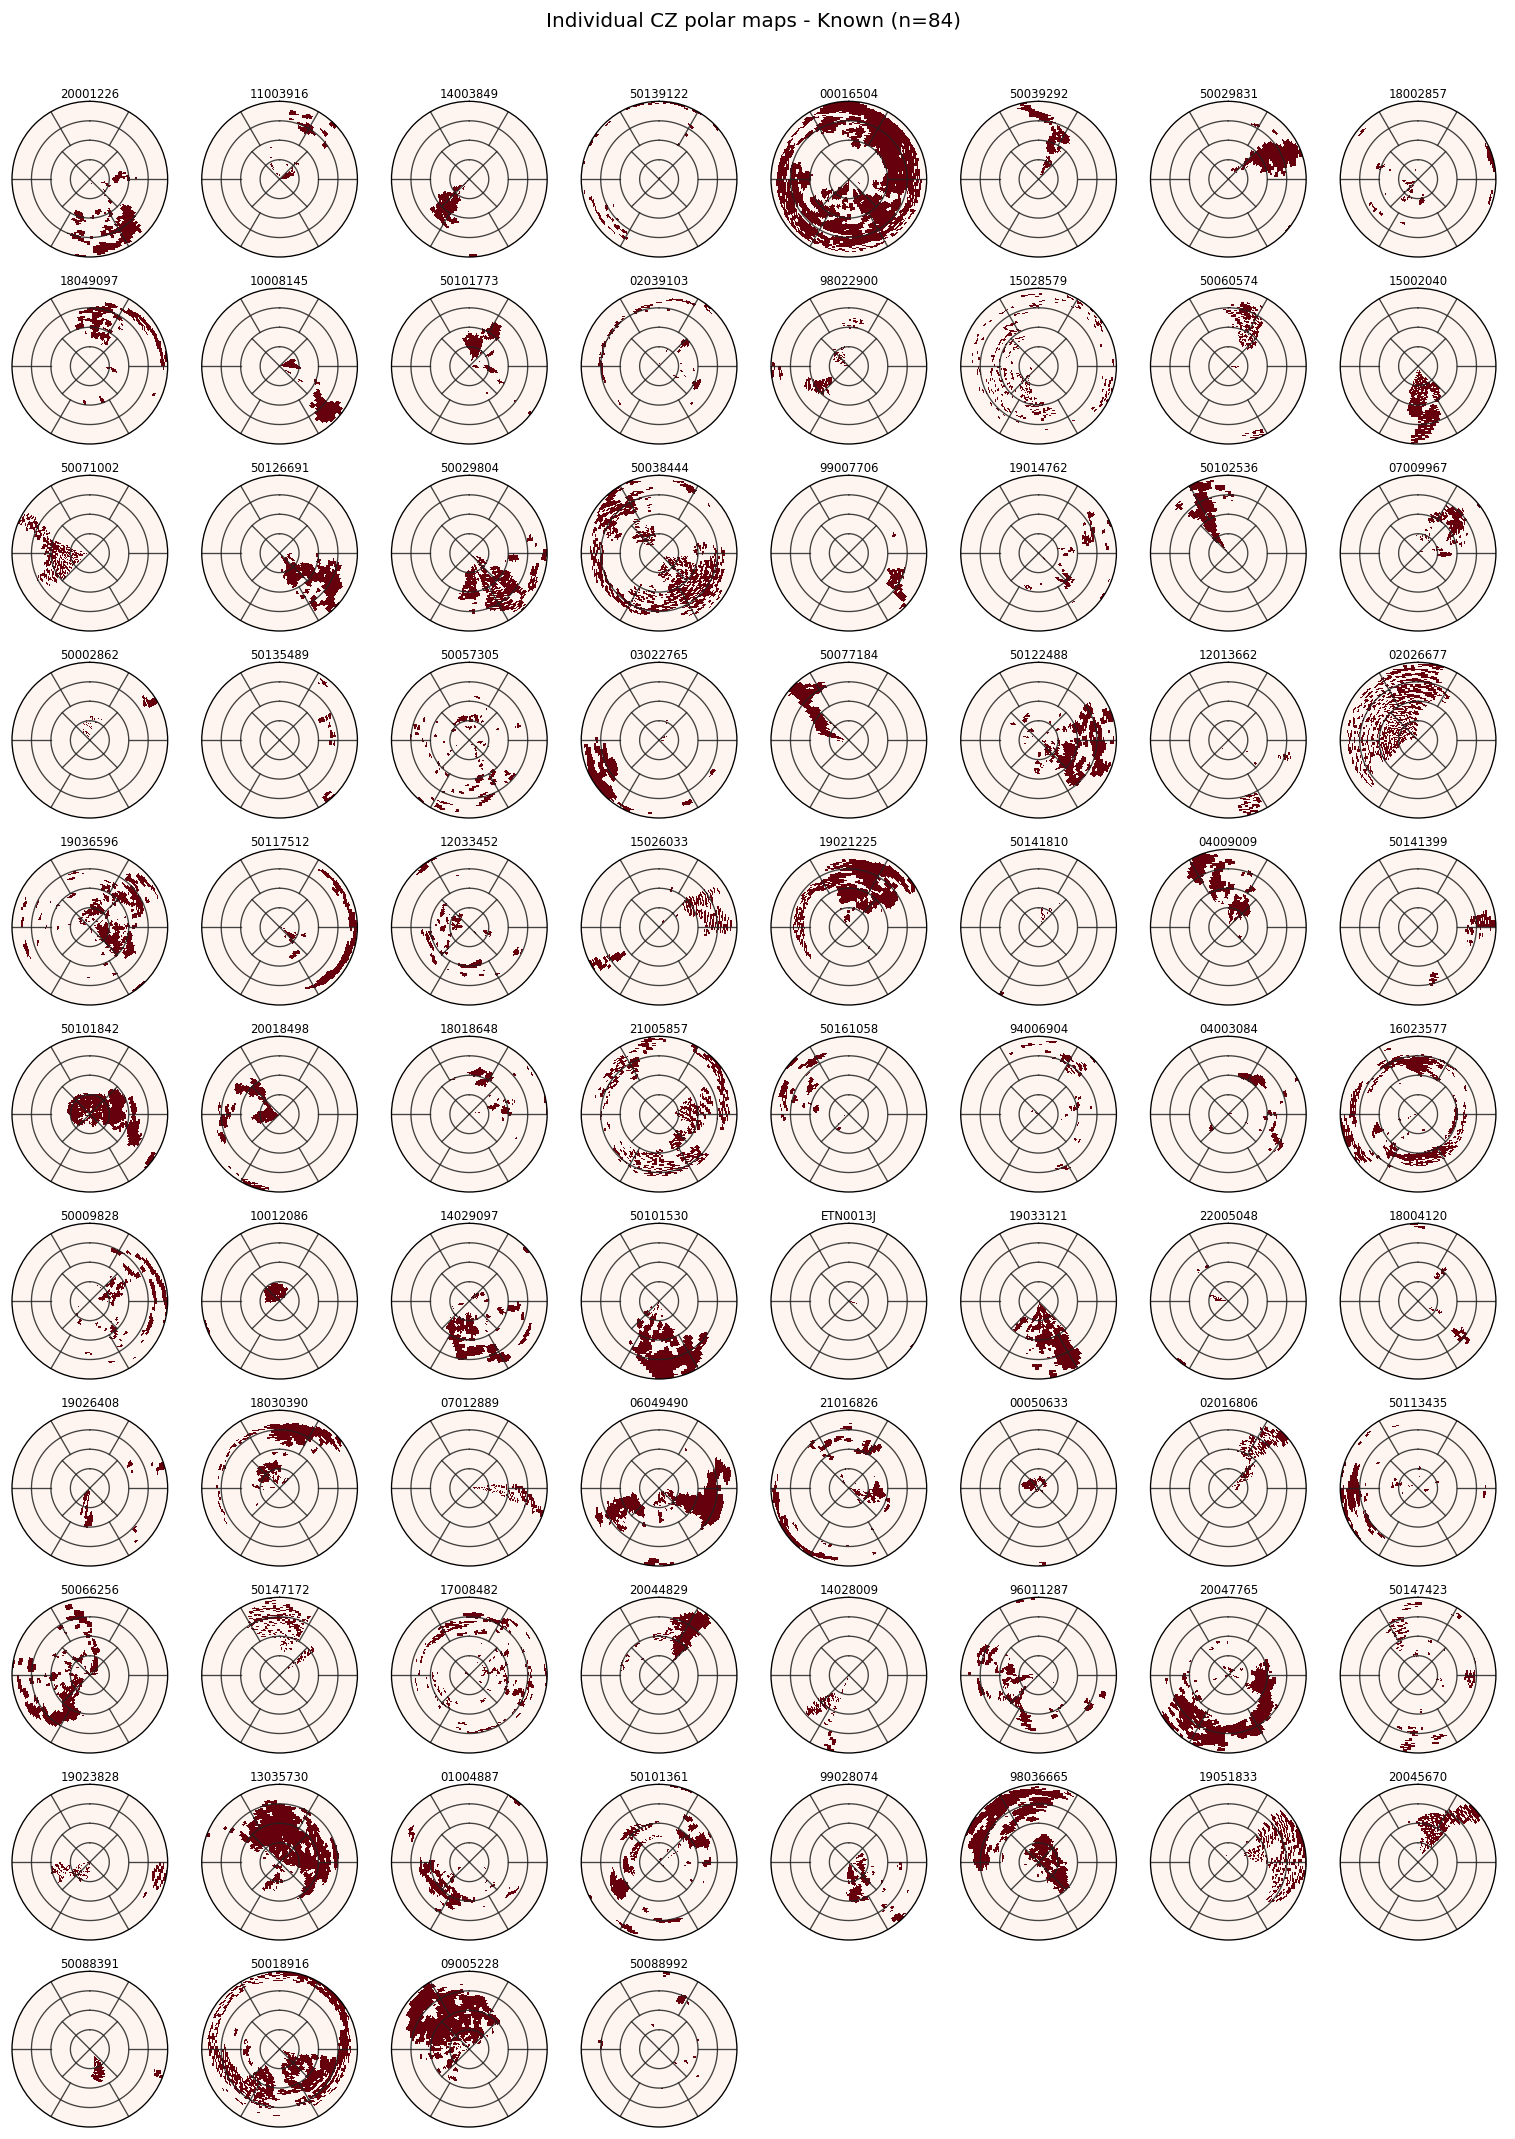

In [10]:
if not pmaps:
    print("No polar maps - check scan.")
else:
    keys  = list(pmaps.keys())
    ncols = 8
    nrows = int(np.ceil(len(keys) / ncols))
    fig   = plt.figure(figsize=(ncols*1.6, nrows*1.6))
    fig.suptitle(f"Individual CZ polar maps - Known (n={len(keys)})", fontsize=12, y=1.01)
    for idx, key in enumerate(keys):
        ax = fig.add_subplot(nrows, ncols, idx+1, projection="polar")
        _draw_bullseye(pmaps[key], ax, title=key.split("/")[1], label_segments=False)
    for idx in range(len(keys), nrows*ncols):
        fig.add_subplot(nrows, ncols, idx+1).axis("off")
    plt.tight_layout()
    plt.savefig(OUT / "polar_grid_known.png", bbox_inches="tight")
    plt.show()


### 4c - Superposition: scar density (default = PCA)

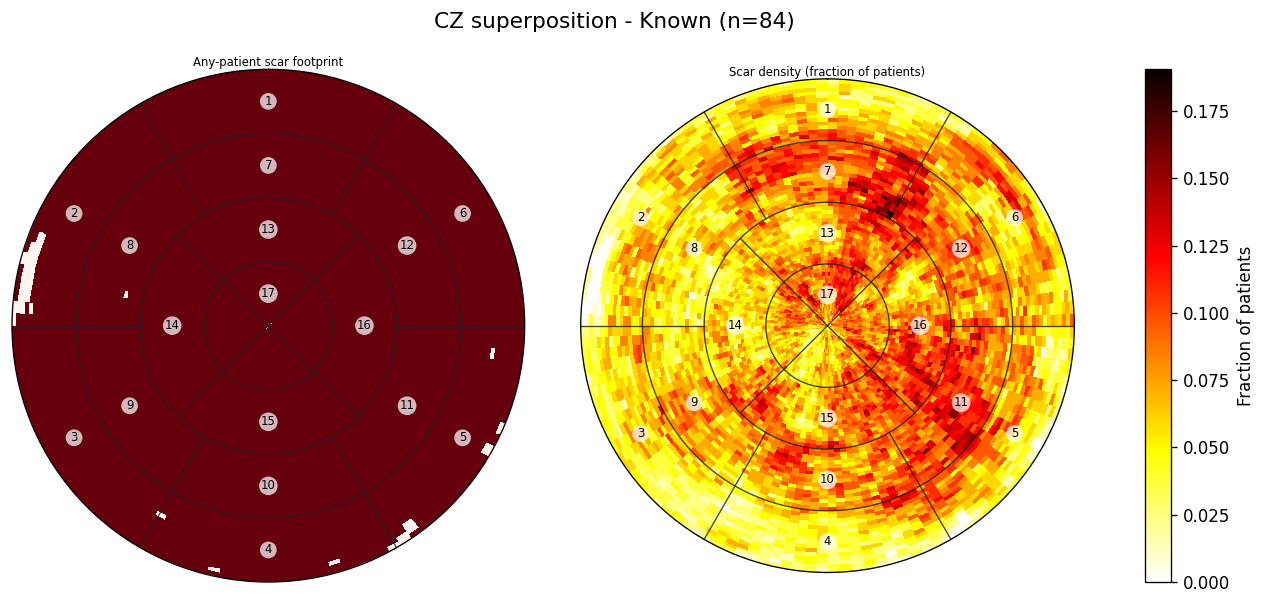

In [11]:
if not pmaps:
    print("No polar maps.")
else:
    stack   = np.stack(list(pmaps.values()))
    density = stack.mean(axis=0)
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={"projection": "polar"})
    fig.suptitle(f"CZ superposition - Known (n={len(pmaps)})", fontsize=13)
    _draw_bullseye(density > 0, ax_l, title="Any-patient scar footprint", label_segments=True)
    _draw_bullseye(density, ax_r, title="Scar density (fraction of patients)", cmap="hot_r", vmax=density.max(), label_segments=True)
    sm = plt.cm.ScalarMappable(cmap="hot_r", norm=plt.Normalize(0, density.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax_r, pad=0.12, fraction=0.046, label="Fraction of patients")
    plt.tight_layout()
    plt.savefig(OUT / "polar_superposition_known.png", bbox_inches="tight")
    plt.show()


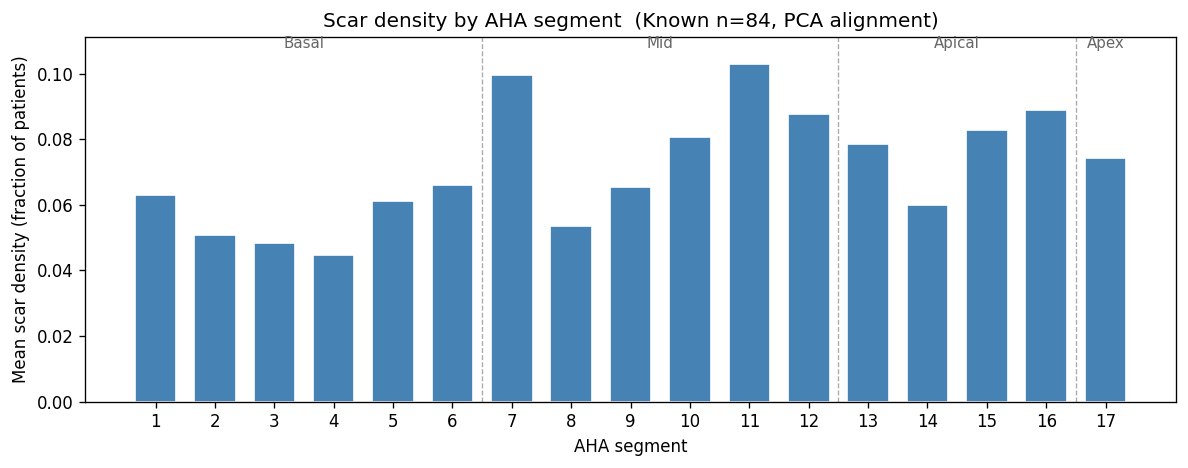

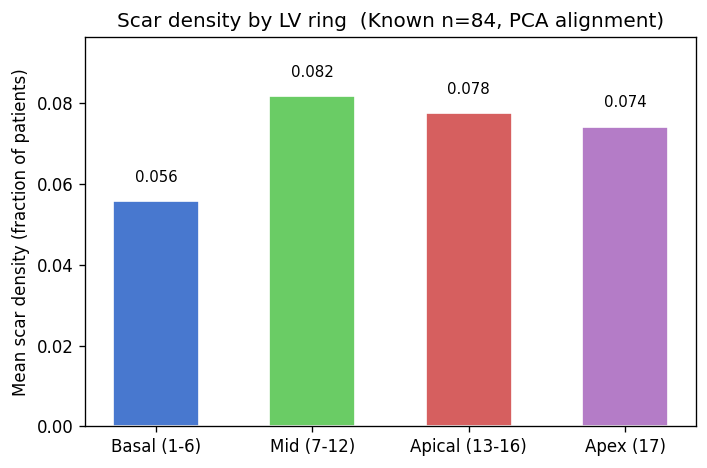

Highest-scar AHA segments: seg 11 (0.10), seg 7 (0.10), seg 16 (0.09)


In [12]:
### 4c-bis - Scar density by AHA segment

if not pmaps:
    print("No polar maps.")
else:
    stack   = np.stack(list(pmaps.values()))
    density = stack.mean(axis=0)          # (N_R, N_THETA) fraction of patients

    n_r, n_theta = density.shape
    r_vals = (np.arange(n_r)     + 0.5) / n_r         # centre of each radial bin  [0,1]
    t_vals = (np.arange(n_theta) + 0.5) / n_theta * 360  # centre of each theta bin [0,360)
    R, T   = np.meshgrid(r_vals, t_vals, indexing='ij')  # (n_r, n_theta)

    def _grid_to_aha(r, theta_deg):
        """Return AHA segment (1-17) for a polar-map grid cell."""
        if r < 0.25:
            return 17
        th = theta_deg % 360
        if r < 0.50:                                   # apical ring (4 segments)
            if   th < 45  or th >= 315: return 13
            elif th < 135:              return 16
            elif th < 225:              return 15
            else:                       return 14
        else:                                          # mid/basal rings (6 segments each)
            if   th < 30  or th >= 330: sector = 0
            elif th < 90:               sector = 1
            elif th < 150:              sector = 2
            elif th < 210:              sector = 3
            elif th < 270:              sector = 4
            else:                       sector = 5
            basal_segs = [1, 6, 5, 4, 3, 2]
            mid_segs   = [7, 12, 11, 10, 9, 8]
            return basal_segs[sector] if r >= 0.75 else mid_segs[sector]

    seg_map = np.vectorize(_grid_to_aha)(R, T)         # (n_r, n_theta)
    seg_density = {s: density[seg_map == s].mean() for s in range(1, 18)}

    segs = list(range(1, 18))
    vals = [seg_density[s] for s in segs]
    top  = max(vals) * 1.08

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(segs, vals, color='steelblue', edgecolor='white', width=0.7)
    ax.set_xlabel("AHA segment")
    ax.set_ylabel("Mean scar density (fraction of patients)")
    ax.set_title(f"Scar density by AHA segment  (Known n={len(pmaps)}, PCA alignment)")
    ax.set_xticks(segs)
    ax.set_ylim(0, top)
    for x, label, x2 in [(3.5, 'Basal', 6.5), (9.5, 'Mid', 12.5), (14.5, 'Apical', 16.5), (17, 'Apex', None)]:
        ax.axvline(x2, color='#aaaaaa', lw=0.8, ls='--') if x2 else None
        ax.text(x, top * 0.97, label, ha='center', fontsize=9, color='#666666')
    plt.tight_layout()
    plt.savefig(OUT / "aha_scar_density.png", bbox_inches='tight')
    plt.show()


    # --- ring-level summary ---
    ring_groups = {
        'Basal (1-6)':    [1, 2, 3, 4, 5, 6],
        'Mid (7-12)':     [7, 8, 9, 10, 11, 12],
        'Apical (13-16)': [13, 14, 15, 16],
        'Apex (17)':      [17],
    }
    ring_vals   = [np.mean([seg_density[s] for s in sg]) for sg in ring_groups.values()]
    ring_names  = list(ring_groups.keys())
    ring_colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']

    fig2, ax2 = plt.subplots(figsize=(6, 4))
    bars2 = ax2.bar(ring_names, ring_vals, color=ring_colors, edgecolor='white', width=0.55)
    for bar, val in zip(bars2, ring_vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax2.set_ylabel('Mean scar density (fraction of patients)')
    ax2.set_title(f'Scar density by LV ring  (Known n={len(pmaps)}, PCA alignment)')
    ax2.set_ylim(0, max(ring_vals) * 1.18)
    plt.tight_layout()
    plt.savefig(OUT / "aha_scar_density_rings.png", bbox_inches='tight')
    plt.show()

    top3 = sorted(seg_density, key=seg_density.get, reverse=True)[:3]
    print("Highest-scar AHA segments:",", ".join(f"seg {s} ({seg_density[s]:.2f})" for s in top3))

### 4d - Method comparison: dip detection vs PCA reference

Two methods are compared for finding the circumferential **theta=0** reference
(septal direction) used to align all polar maps. **Method B (PCA) is the default**;
Method A is retained as a diagnostic baseline:

| | Method A – Dip detection | Method B – PCA |
|---|---|---|
| How | Find 2 deepest radial minima in the smoothed basal ring | PC1 of the 2-D basal cross-section → concave half-axis |
| Pros | Directly targets the concavities; biologically motivated | Global shape statistic; robust to extra noise dips |
| Cons | Top-2 selection fails when artefact dips are deeper than true insertions | Axis ambiguity resolved heuristically (smaller mean radius) |

#### What is the radial profile and why is it shown?

The **radial profile** (column 2 of each row) is a 1-D signal derived from the
basal LV cross-section:

- The basal ring points are projected into the 2-D plane perpendicular to the
  long axis and sorted by their circumferential angle (-180° to +180°).
- For each angular position the **radial distance** from the centroid to the
  LV wall is plotted (gray = raw point cloud, black = smoothed).
- A **perfectly round** LV would be a flat horizontal line.
- The two **RV attachment concavities** appear as valleys (local minima).
  These are the anatomical targets both methods try to locate.
- Noisy / hand-segmented meshes show many additional spurious valleys.

**Why it is useful:**
1. *Segmentation quality indicator* – count how many dips appear; more than ~3
   signals a rough or artefact-heavy contour.
2. *Algorithm transparency* – the dashed red lines mark **all** detected dip
   positions; the solid red line is the Method A reference angle; the solid blue
   line is the Method B (PCA) reference angle. When solid lines align with the
   two deepest dashes the algorithm is working as intended; when they diverge
   an artefact dip was wrongly selected.
3. *Confidence indicator* – large angular gap between the red and blue solid
   lines (big Δ) means neither method is trustworthy for that case.

#### Interpreting the diagnostic grid

Each row = one case, sorted from largest to smallest Δ (angle disagreement):
- **Col 1 – basal ring**: scatter of ring points coloured by radius. Gray × =
  all detected dips, red ● = top-2 selected by Method A. Red arrow = Method A
  reference direction; blue arrow = Method B.
- **Col 2 – radial profile**: see above. When Method A picks the wrong two
  dips, the solid red line will sit at an artefact valley while the blue line
  sits at the true septal region.
- **Col 3/4 – bull’s-eyes**: the resulting polar map for each method. A
  correct septal reference produces an anatomically plausible scar location
  (typically inferior-septal / mid-wall). A wrong reference rotates the
  entire map, spreading the scar artificially.

#### Superposition comparison

The 4-panel figure (cell below) shows the mean scar density across all patients
for each method. A **more concentrated hot-spot** pattern indicates better
inter-patient alignment. If the map is uniformly dark, the reference is
inconsistent across patients and the superposition washes out.


In [13]:
def _ring_debug_data(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Return basal-ring 2-D data, dip peaks, and both reference directions."""
    u, w = _plane_basis(axis)
    pts  = np.array(lv_mesh.points)
    proj = (pts - apex) @ axis
    span = proj.max() - proj.min()
    mask = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring = pts[mask]
    if len(ring) < 20:
        return None
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    angles   = np.arctan2(diff[:, 1], diff[:, 0])
    radii    = np.linalg.norm(diff, axis=1)
    idx      = np.argsort(angles)
    smooth_r = uniform_filter1d(radii[idx], size=max(3, len(radii)//20), mode='wrap')
    peaks, _ = find_peaks(-smooth_r, distance=max(5, len(smooth_r)//8))
    top2     = peaks[np.argsort(-smooth_r[peaks])[:2]] if len(peaks) >= 2 else peaks
    all_dip_pts = diff[idx[peaks]] if len(peaks) > 0 else np.zeros((0, 2))
    top2_pts    = diff[idx[top2]]  if len(top2)  > 0 else np.zeros((0, 2))
    ref_dip = _rv_reference(lv_mesh, axis, apex)
    ref_pca = _rv_reference_pca(lv_mesh, axis, apex)
    dir_dip = np.array([np.dot(ref_dip, u), np.dot(ref_dip, w)])
    dir_pca = np.array([np.dot(ref_pca, u), np.dot(ref_pca, w)])
    return dict(diff=diff, angles_sorted=angles[idx], radii_sorted=radii[idx],
                smooth_r=smooth_r, all_dip_pts=all_dip_pts, top2_pts=top2_pts,
                n_dips=len(peaks), dir_dip=dir_dip, dir_pca=dir_pca)


def _angle_diff_deg(a, b):
    d = abs(a - b) % (2 * np.pi)
    return float(np.degrees(min(d, 2*np.pi - d)))


pmaps_pca  = dict(pmaps)
pmaps_dip  = {}
ref_angles = {}   # key -> (angle_dip_deg, angle_pca_deg, diff_deg)
for case in tqdm(known, desc='Dip polar maps'):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps_dip[key] = polar_map(case, ref_fn=_rv_reference)
        shell = _best_shell(case)
        axis, apex = _long_axis(shell)
        u, w = _plane_basis(axis)
        ra = _rv_reference(shell, axis, apex)
        rb = _rv_reference_pca(shell, axis, apex)
        a_dip = np.arctan2(np.dot(ra, w), np.dot(ra, u))
        a_pca = np.arctan2(np.dot(rb, w), np.dot(rb, u))
        ref_angles[key] = (np.degrees(a_dip) % 360,
                           np.degrees(a_pca) % 360,
                           _angle_diff_deg(a_dip, a_pca))
    except Exception as e:
        print(f"  skip {key}: {e}")

if ref_angles:
    diffs = np.array([v[2] for v in ref_angles.values()])
    print(f"Cases computed        : {len(ref_angles)}")
    print(f"Mean  angle diff      : {diffs.mean():.1f}°")
    print(f"Median angle diff     : {np.median(diffs):.1f}°")
    print(f"Max   angle diff      : {diffs.max():.1f}°")
    for thresh in [10, 20, 30]:
        n = (diffs > thresh).sum()
        print(f"Cases with diff > {thresh}°  : {n}")
    print()
    print('Most disagreeing cases (sorted):')
    for k, (ad, ap, diff) in sorted(ref_angles.items(), key=lambda x: -x[1][2])[:10]:
        print(f"  {k:30s}  dip={ad:6.1f}°  pca={ap:6.1f}°  Δ={diff:5.1f}°")


Dip polar maps: 100%|██████████| 84/84 [00:02<00:00, 29.12it/s]

Cases computed        : 84
Mean  angle diff      : 40.1°
Median angle diff     : 26.0°
Max   angle diff      : 155.2°
Cases with diff > 10°  : 63
Cases with diff > 20°  : 49
Cases with diff > 30°  : 37

Most disagreeing cases (sorted):
  2024/19014762                   dip= 326.0°  pca= 170.8°  Δ=155.2°
  2024/50139122                   dip= 331.9°  pca= 189.2°  Δ=142.8°
  2024/09005228                   dip= 149.3°  pca=  22.7°  Δ=126.6°
  2024/50101842                   dip= 264.5°  pca=  11.9°  Δ=107.4°
  2021/20045670                   dip=  80.3°  pca= 179.8°  Δ= 99.6°
  2024/04009009                   dip= 279.4°  pca= 183.9°  Δ= 95.5°
  2024/02039103                   dip= 287.4°  pca=  19.8°  Δ= 92.4°
  2023/00050633                   dip= 191.2°  pca= 283.4°  Δ= 92.1°
  2024/07009967                   dip= 280.7°  pca= 191.4°  Δ= 89.3°
  2025/50071002                   dip= 279.2°  pca= 190.8°  Δ= 88.4°


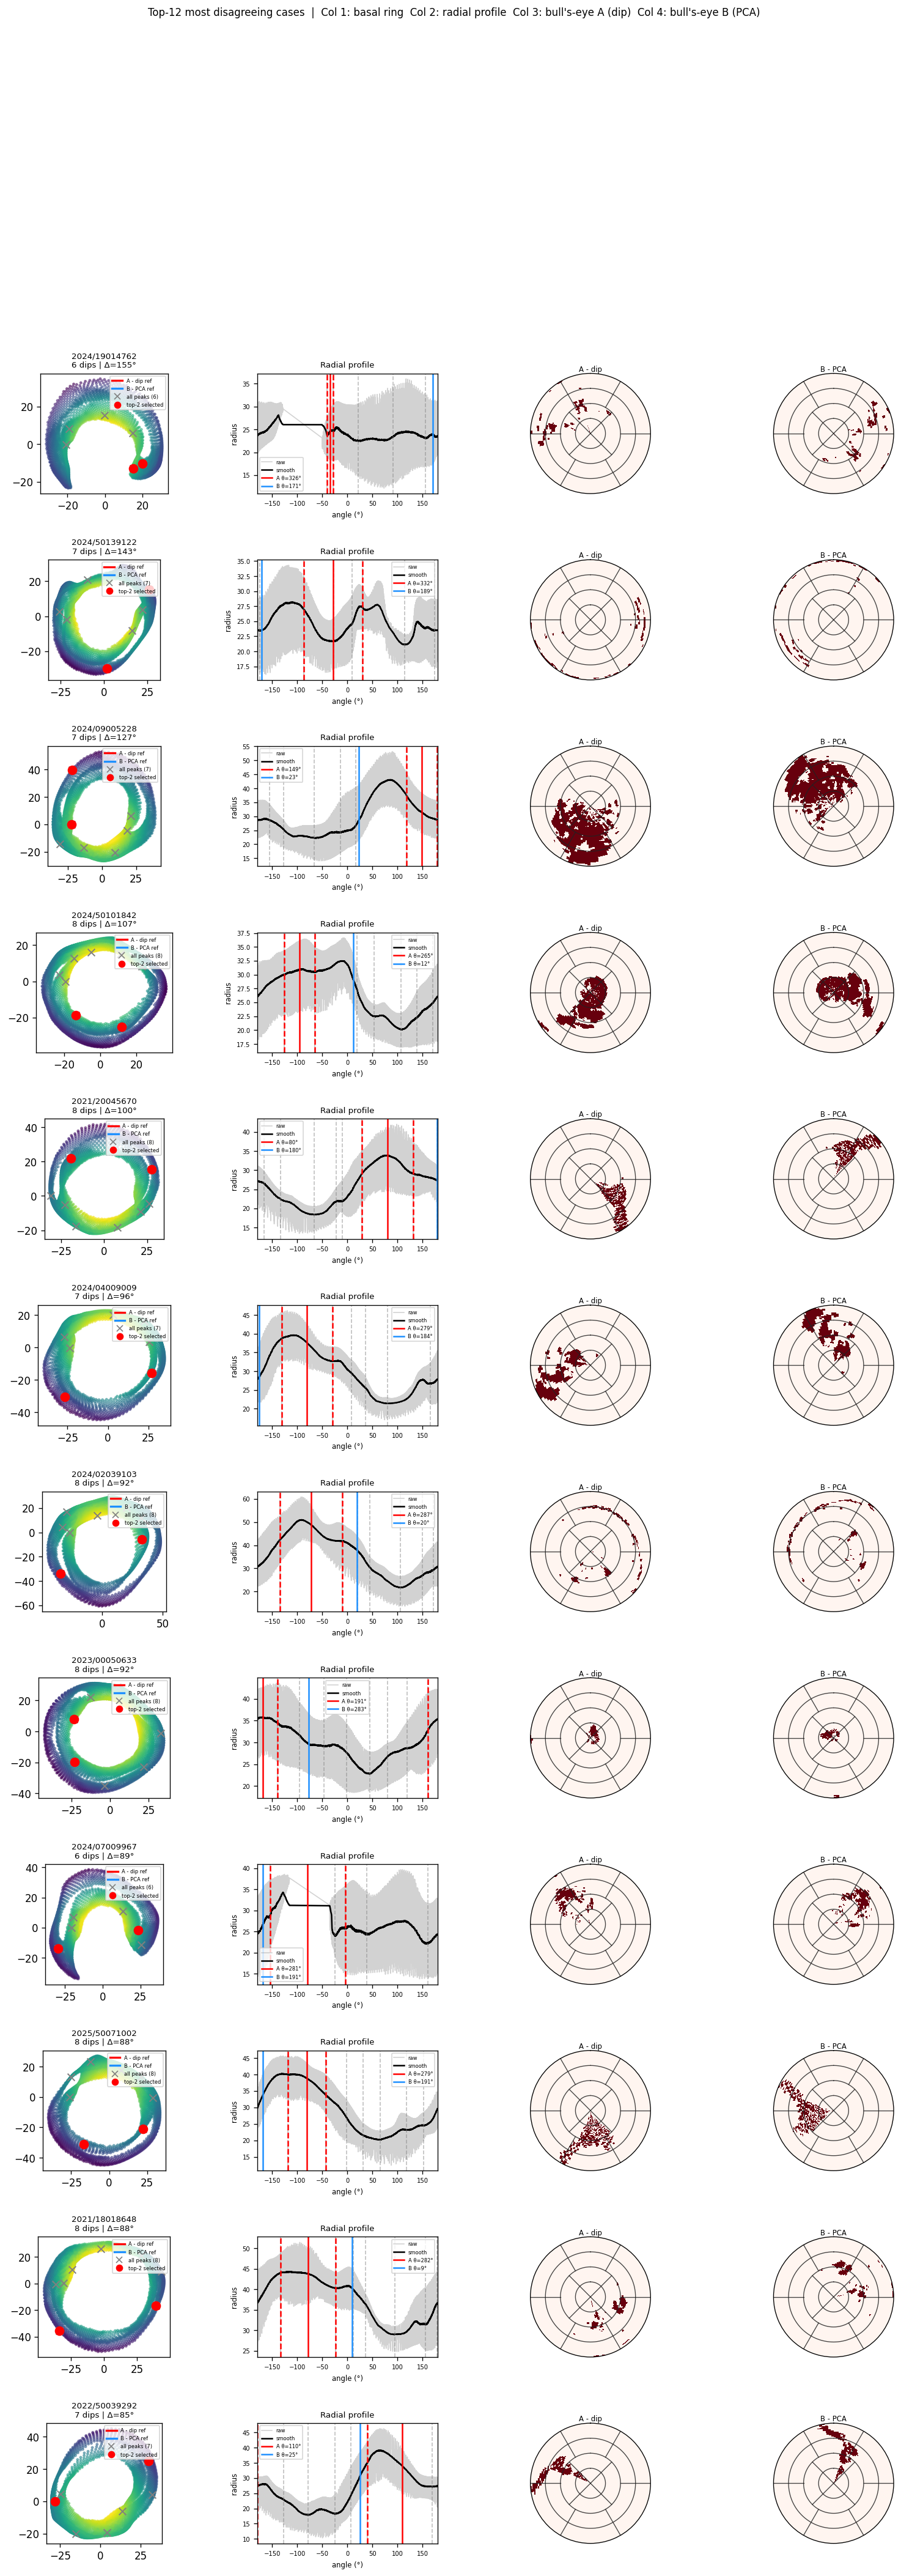

Saved -> results/method_comparison_diagnostic.png


In [14]:
DIAG_TOP_N = 12   # how many disagreeing cases to display

sorted_cases = sorted(ref_angles.items(), key=lambda x: -x[1][2])
diag_cases   = sorted_cases[:DIAG_TOP_N]

nrows = len(diag_cases)
if nrows == 0:
    print('No cases to show.')
else:
    fig = plt.figure(figsize=(16, nrows * 3.2))
    fig.suptitle(
        f"Top-{nrows} most disagreeing cases  |  "
        "Col 1: basal ring  Col 2: radial profile  "
        "Col 3: bull's-eye A (dip)  Col 4: bull's-eye B (PCA)",
        fontsize=10, y=1.01)
    gs = gridspec.GridSpec(nrows, 4, figure=fig, hspace=0.55, wspace=0.35)

    for row, (key, (ad, ap, diff_deg)) in enumerate(diag_cases):
        year, pid = key.split('/')
        case  = next(c for c in known if c.patient_id == pid and str(c.year) == year)
        shell = _best_shell(case)
        axis, apex = _long_axis(shell)
        data  = _ring_debug_data(shell, axis, apex)

        ax_ring    = fig.add_subplot(gs[row, 0])
        ax_profile = fig.add_subplot(gs[row, 1])
        ax_dip_map = fig.add_subplot(gs[row, 2], projection='polar')
        ax_pca_map = fig.add_subplot(gs[row, 3], projection='polar')

        if data is None:
            for ax in [ax_ring, ax_profile, ax_dip_map, ax_pca_map]:
                ax.axis('off')
            ax_ring.set_title(f"{key}\nno ring data", fontsize=8)
            continue

        # Ring scatter
        d2 = data['diff']
        r2 = np.linalg.norm(d2, axis=1)
        ax_ring.scatter(d2[:, 0], d2[:, 1], c=r2, cmap='viridis_r', s=4, alpha=0.5)
        if len(data['all_dip_pts']) > 0:
            ax_ring.scatter(data['all_dip_pts'][:, 0], data['all_dip_pts'][:, 1],
                            marker='x', c='gray', s=50, linewidths=1.2, zorder=3)
        if len(data['top2_pts']) > 0:
            ax_ring.scatter(data['top2_pts'][:, 0], data['top2_pts'][:, 1],
                            marker='o', c='red', s=70, zorder=4)
        scale = r2.max() * 1.3
        ax_ring.annotate('', xy=data['dir_dip'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='red', lw=2.0))
        ax_ring.annotate('', xy=data['dir_pca'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.0))
        ax_ring.set_aspect('equal')
        ax_ring.set_title(f"{key}\n{data['n_dips']} dips | Δ={diff_deg:.0f}°", fontsize=8)
        handles = [
            plt.Line2D([0],[0], color='red',       lw=2, label='A - dip ref'),
            plt.Line2D([0],[0], color='dodgerblue', lw=2, label='B - PCA ref'),
            plt.Line2D([0],[0], marker='x', color='gray', ls='None',
                       markersize=6, label=f"all peaks ({data['n_dips']})"),
            plt.Line2D([0],[0], marker='o', color='red', ls='None',
                       markersize=6, label='top-2 selected'),
        ]
        ax_ring.legend(handles=handles, fontsize=5, loc='upper right')

        # Radial profile
        ang_deg = np.degrees(data['angles_sorted'])
        ax_profile.plot(ang_deg, data['radii_sorted'], alpha=0.35, color='gray', lw=1, label='raw')
        ax_profile.plot(ang_deg, data['smooth_r'], color='black', lw=1.5, label='smooth')
        for pk_pt in data['all_dip_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='gray', alpha=0.5, lw=1, ls='--')
        for pk_pt in data['top2_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='red', lw=1.5, ls='--')
        ax_profile.axvline(ad if ad <= 180 else ad - 360, color='red',
                           lw=1.5, ls='-', label=f'A θ={ad:.0f}°')
        ax_profile.axvline(ap if ap <= 180 else ap - 360, color='dodgerblue',
                           lw=1.5, ls='-', label=f'B θ={ap:.0f}°')
        ax_profile.set_xlim(-180, 180)
        ax_profile.set_xlabel('angle (°)', fontsize=7)
        ax_profile.set_ylabel('radius', fontsize=7)
        ax_profile.set_title('Radial profile', fontsize=8)
        ax_profile.legend(fontsize=5)
        ax_profile.tick_params(labelsize=6)

        # Bull's-eyes
        if key in pmaps_dip:
            _draw_bullseye(pmaps_dip[key], ax_dip_map, title='A - dip', label_segments=False)
        else:
            ax_dip_map.axis('off')
        if key in pmaps_pca:
            _draw_bullseye(pmaps_pca[key], ax_pca_map, title='B - PCA', label_segments=False)
        else:
            ax_pca_map.axis('off')

    plt.savefig(OUT / 'method_comparison_diagnostic.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_diagnostic.png')


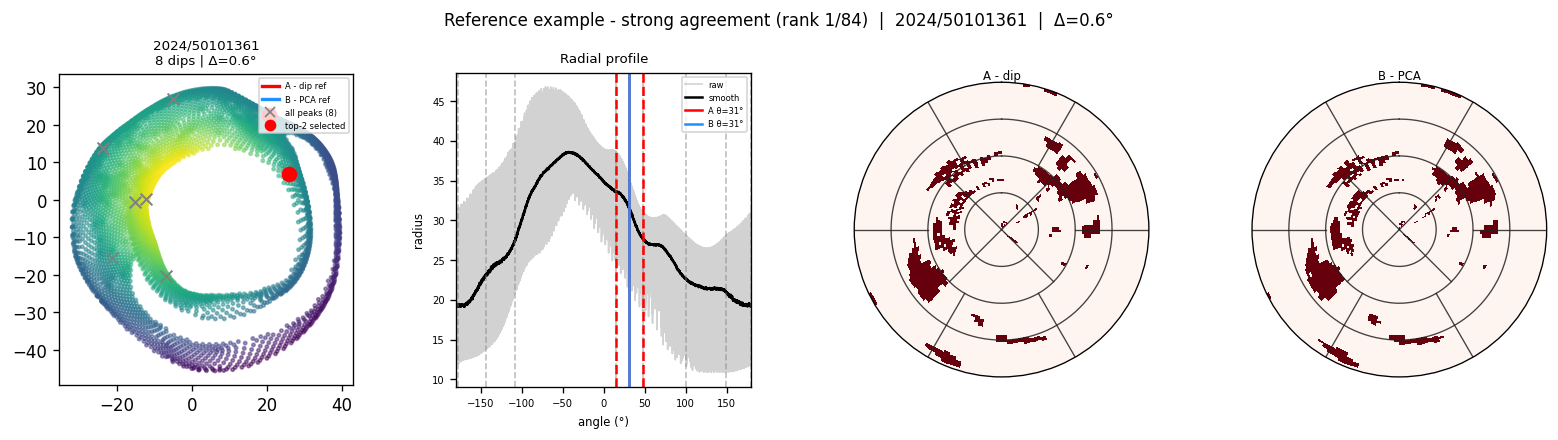

Saved -> results/method_comparison_reference_case.png


In [15]:
GOOD_CASE_RANK = 0   # 0 = lowest-disagreement case; increase to inspect the next-best aligned case

good_cases = sorted(ref_angles.items(), key=lambda x: x[1][2])
if not good_cases:
    print('No reference-angle diagnostics available.')
else:
    rank = int(np.clip(GOOD_CASE_RANK, 0, len(good_cases) - 1))
    key, (ad, ap, diff_deg) = good_cases[rank]
    year, pid = key.split('/')
    case  = next(c for c in known if c.patient_id == pid and str(c.year) == year)
    shell = _best_shell(case)
    axis, apex = _long_axis(shell)
    data  = _ring_debug_data(shell, axis, apex)

    fig = plt.figure(figsize=(16, 3.4))
    fig.suptitle(
        f"Reference example - strong agreement (rank {rank + 1}/{len(good_cases)})  |  {key}  |  Δ={diff_deg:.1f}°",
        fontsize=10, y=1.03)
    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

    ax_ring    = fig.add_subplot(gs[0, 0])
    ax_profile = fig.add_subplot(gs[0, 1])
    ax_dip_map = fig.add_subplot(gs[0, 2], projection='polar')
    ax_pca_map = fig.add_subplot(gs[0, 3], projection='polar')

    if data is None:
        for ax in [ax_ring, ax_profile, ax_dip_map, ax_pca_map]:
            ax.axis('off')
        ax_ring.set_title(f"{key}\nno ring data", fontsize=8)
    else:
        d2 = data['diff']
        r2 = np.linalg.norm(d2, axis=1)
        ax_ring.scatter(d2[:, 0], d2[:, 1], c=r2, cmap='viridis_r', s=4, alpha=0.5)
        if len(data['all_dip_pts']) > 0:
            ax_ring.scatter(data['all_dip_pts'][:, 0], data['all_dip_pts'][:, 1],
                            marker='x', c='gray', s=50, linewidths=1.2, zorder=3)
        if len(data['top2_pts']) > 0:
            ax_ring.scatter(data['top2_pts'][:, 0], data['top2_pts'][:, 1],
                            marker='o', c='red', s=70, zorder=4)
        scale = r2.max() * 1.3
        ax_ring.annotate('', xy=data['dir_dip'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='red', lw=2.0))
        ax_ring.annotate('', xy=data['dir_pca'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.0))
        ax_ring.set_aspect('equal')
        ax_ring.set_title(f"{key}\n{data['n_dips']} dips | Δ={diff_deg:.1f}°", fontsize=8)
        handles = [
            plt.Line2D([0],[0], color='red', lw=2, label='A - dip ref'),
            plt.Line2D([0],[0], color='dodgerblue', lw=2, label='B - PCA ref'),
            plt.Line2D([0],[0], marker='x', color='gray', ls='None',
                       markersize=6, label=f"all peaks ({data['n_dips']})"),
            plt.Line2D([0],[0], marker='o', color='red', ls='None',
                       markersize=6, label='top-2 selected'),
        ]
        ax_ring.legend(handles=handles, fontsize=5, loc='upper right')

        ang_deg = np.degrees(data['angles_sorted'])
        ax_profile.plot(ang_deg, data['radii_sorted'], alpha=0.35, color='gray', lw=1, label='raw')
        ax_profile.plot(ang_deg, data['smooth_r'], color='black', lw=1.5, label='smooth')
        for pk_pt in data['all_dip_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='gray', alpha=0.5, lw=1, ls='--')
        for pk_pt in data['top2_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='red', lw=1.5, ls='--')
        ax_profile.axvline(ad if ad <= 180 else ad - 360, color='red',
                           lw=1.5, ls='-', label=f'A θ={ad:.0f}°')
        ax_profile.axvline(ap if ap <= 180 else ap - 360, color='dodgerblue',
                           lw=1.5, ls='-', label=f'B θ={ap:.0f}°')
        ax_profile.set_xlim(-180, 180)
        ax_profile.set_xlabel('angle (°)', fontsize=7)
        ax_profile.set_ylabel('radius', fontsize=7)
        ax_profile.set_title('Radial profile', fontsize=8)
        ax_profile.legend(fontsize=5)
        ax_profile.tick_params(labelsize=6)

        if key in pmaps_dip:
            _draw_bullseye(pmaps_dip[key], ax_dip_map, title='A - dip', label_segments=False)
        else:
            ax_dip_map.axis('off')
        if key in pmaps_pca:
            _draw_bullseye(pmaps_pca[key], ax_pca_map, title='B - PCA', label_segments=False)
        else:
            ax_pca_map.axis('off')

    plt.savefig(OUT / 'method_comparison_reference_case.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_reference_case.png')


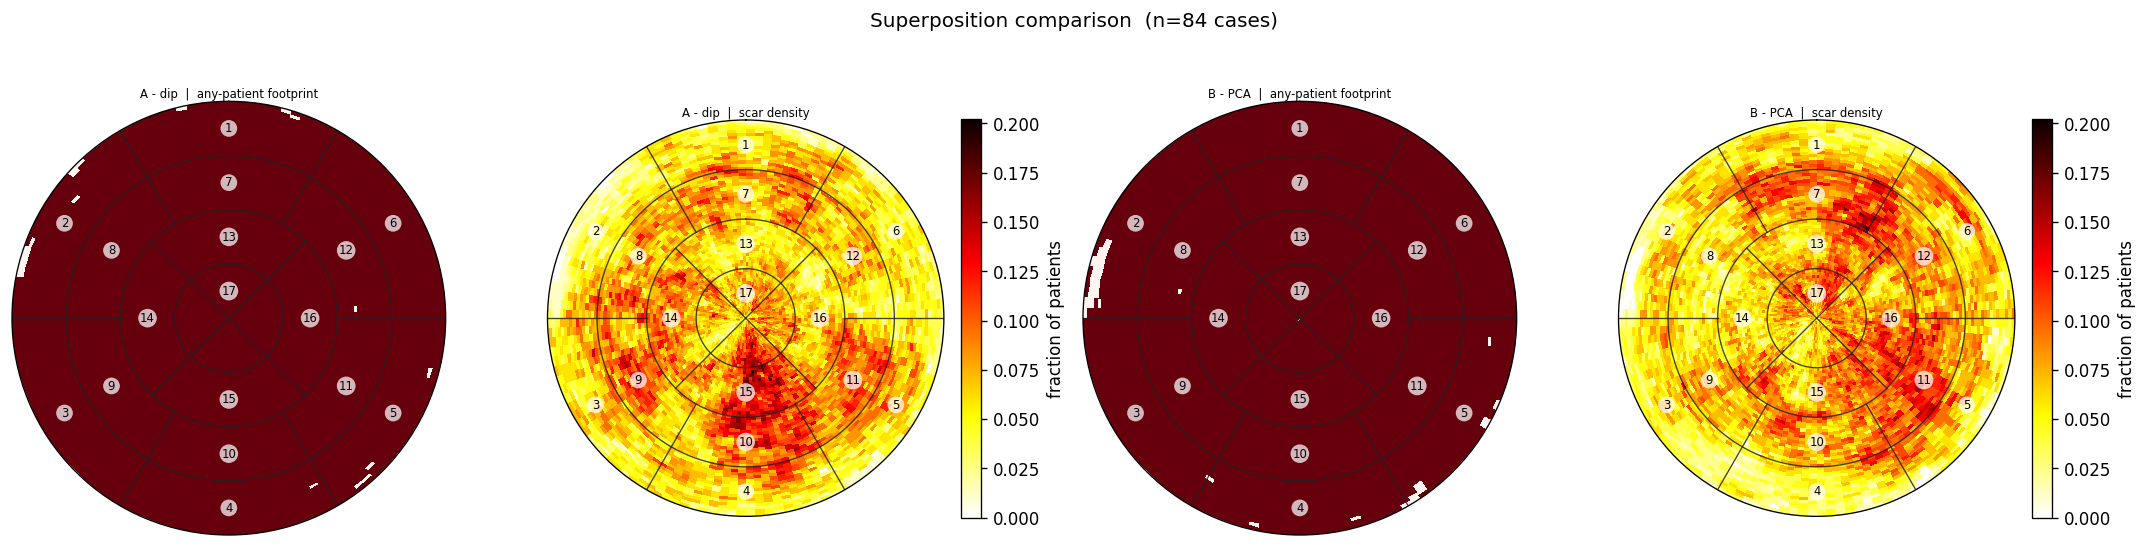

Saved -> results/method_comparison_superposition.png


In [16]:
common = sorted(set(pmaps_dip) & set(pmaps_pca))
if not common:
    print('No common cases.')
else:
    stack_dip = np.stack([pmaps_dip[k] for k in common])
    stack_pca = np.stack([pmaps_pca[k] for k in common])
    dens_dip  = stack_dip.mean(axis=0)
    dens_pca  = stack_pca.mean(axis=0)
    vmax      = max(dens_dip.max(), dens_pca.max())

    fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                             subplot_kw={'projection': 'polar'})
    fig.suptitle(f"Superposition comparison  (n={len(common)} cases)", fontsize=12)

    _draw_bullseye(dens_dip > 0, axes[0], title="A - dip  |  any-patient footprint", label_segments=True)
    _draw_bullseye(dens_dip,     axes[1], title="A - dip  |  scar density",
                   cmap='hot_r', vmax=vmax, label_segments=True)
    _draw_bullseye(dens_pca > 0, axes[2], title="B - PCA  |  any-patient footprint", label_segments=True)
    _draw_bullseye(dens_pca,     axes[3], title="B - PCA  |  scar density",
                   cmap='hot_r', vmax=vmax, label_segments=True)

    sm = plt.cm.ScalarMappable(cmap='hot_r', norm=plt.Normalize(0, vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04,
                 label='fraction of patients')
    fig.colorbar(sm, ax=axes[3], fraction=0.046, pad=0.04,
                 label='fraction of patients')
    plt.tight_layout()
    plt.savefig(OUT / 'method_comparison_superposition.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_superposition.png')


## 5 - ISOMAP shape analysis

| Situation | Action |
|---|---|
| 1 fragment | ISOMAP on all vertices |
| N fragments | ISOMAP on each fragment separately + fragmentation features |

Why per-fragment: geodesic distances between disconnected islands are infinite.
Running ISOMAP independently per fragment avoids a corrupted distance matrix.

Important: the ISOMAP axes are **arbitrary embedding coordinates**, not anatomical X/Y/Z axes.
A star-like or wing-like shape does **not** mean the scar literally has 3 Cartesian axes; it means
the 2-D embedding is unfolding the fragment geometry that way.

Colours identify fragment rank within each case: blue = largest fragment (F1), orange = second (F2),
green = third (F3), red = fourth (F4), etc. They do not encode anatomy.

Panel title convention: `(3f) [-18 tiny]` means 3 fragments were kept for analysis and 18 extra
tiny connected components were dropped by the `MIN_VERTS_FRAGMENT` filter.

Tiny disconnected islands are often segmentation noise rather than meaningful scar islands.
To reduce clutter, fragments with fewer than MIN_VERTS_FRAGMENT vertices are dropped before the
fragment count and ISOMAP plot are produced. Fragments with fewer than MIN_VERTS_ISOMAP vertices
are kept in the count but not embedded.

Future note: area-based filtering would be better than vertex-count filtering, but the current
vertex threshold is a practical first pass.

In [17]:
@dataclass
class CZAnalysis:
    key:                  str
    raw_n_fragments:      int
    n_fragments:          int
    dropped_fragments:    int
    vertex_counts:        list
    largest_fraction:     float
    centroids:            np.ndarray
    centroid_dist_matrix: np.ndarray
    fragment_meshes:      list
    embeddings:           list

    @property
    def is_compact(self):
        return self.n_fragments == 1


def _run_isomap(pts, k=ISOMAP_K, n_pts=ISOMAP_PTS):
    if len(pts) > n_pts:
        idx = np.random.default_rng(SEED).choice(len(pts), n_pts, replace=False)
        pts = pts[idx]
    k_actual = min(k, len(pts) - 1)
    return Isomap(n_neighbors=k_actual, n_components=2).fit_transform(pts)


def _normalise_embedding(emb):
    emb = np.asarray(emb, dtype=float)
    emb = emb - emb.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(emb, axis=1).max()
    if scale > 0:
        emb = emb / scale
    return emb


def _connected_fragments(mesh):
    """Return one cleaned surface mesh per connected scar fragment.

    connectivity() labels regions, but RegionId may live on cell data while
    mesh.points is point data. Threshold each region into its own sub-mesh
    to avoid point/cell indexing mismatches.
    """
    labeled = mesh.connectivity(largest=False)
    if 'RegionId' in labeled.cell_data:
        region_ids = np.unique(np.asarray(labeled.cell_data['RegionId']).astype(int))
    elif 'RegionId' in labeled.point_data:
        region_ids = np.unique(np.asarray(labeled.point_data['RegionId']).astype(int))
    else:
        return [mesh]

    fragments = []
    for rid in region_ids:
        piece = labeled.threshold((rid - 0.5, rid + 0.5), scalars='RegionId')
        piece = piece.extract_surface().clean()
        if piece.n_points > 0:
            fragments.append(piece)
    fragments.sort(key=lambda m: m.n_points, reverse=True)
    return fragments


def _filter_fragments(fragments, min_points=MIN_VERTS_FRAGMENT):
    kept = [frag for frag in fragments if frag.n_points >= min_points]
    if kept:
        return kept
    return fragments[:1]


def analyze_cz(case):
    key       = f"{case.year}/{case.patient_id}"
    cz        = pv.read(str(case.tissue_surfaces["core"]))
    fragments_all = _connected_fragments(cz)
    raw_n_frags   = len(fragments_all)
    fragments     = _filter_fragments(fragments_all)
    n_frags       = len(fragments)
    if n_frags == 0:
        raise ValueError('no connected scar fragments found')
    dropped_fragments = raw_n_frags - n_frags

    vertex_counts, centroids, embeddings = [], [], []
    for frag in fragments:
        pts = np.array(frag.points)
        vertex_counts.append(len(pts))
        centroids.append(pts.mean(axis=0))
        if len(pts) >= MIN_VERTS_ISOMAP:
            try:
                embeddings.append(_normalise_embedding(_run_isomap(pts)))
            except Exception as e:
                print(f"    ISOMAP failed {key}: {e}")
                embeddings.append(None)
        else:
            embeddings.append(None)
    centroids = np.array(centroids)
    dist_mat  = cdist(centroids, centroids) if len(centroids) > 1 else np.zeros((1, 1))
    return CZAnalysis(
        key=key, raw_n_fragments=raw_n_frags, n_fragments=n_frags,
        dropped_fragments=dropped_fragments,
        vertex_counts=vertex_counts,
        largest_fraction=vertex_counts[0] / max(sum(vertex_counts), 1),
        centroids=centroids, centroid_dist_matrix=dist_mat,
        fragment_meshes=fragments, embeddings=embeddings,
    )

print("CZAnalysis helpers ready.")


CZAnalysis helpers ready.


### 5a - Run analysis on Known set

In [18]:
analyses = {}
for case in tqdm(known, desc="ISOMAP analysis"):
    key = f"{case.year}/{case.patient_id}"
    try:
        analyses[key] = analyze_cz(case)
    except Exception as e:
        print(f"  skip {key}: {e}")

compact    = [a for a in analyses.values() if a.is_compact]
fragmented = [a for a in analyses.values() if not a.is_compact]
print(f"Analysed        : {len(analyses)}")
print(f"Compact (1 frag): {len(compact)}")
print(f"Fragmented (>1) : {len(fragmented)}")


ISOMAP analysis:   0%|          | 0/84 [00:00<?, ?it/s]C:\Users\joan\AppData\Local\Temp\ipykernel_25588\1341867085.py:54: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_25588\1341867085.py:54: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_25588\1341867085.py:54: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in th

Analysed        : 84
Compact (1 frag): 9
Fragmented (>1) : 75


### 5b - ISOMAP embedding grid

- Gray border = compact (1 fragment)
- Orange border = fragmented (each fragment a different colour)
- x marker = fragment too small to embed

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

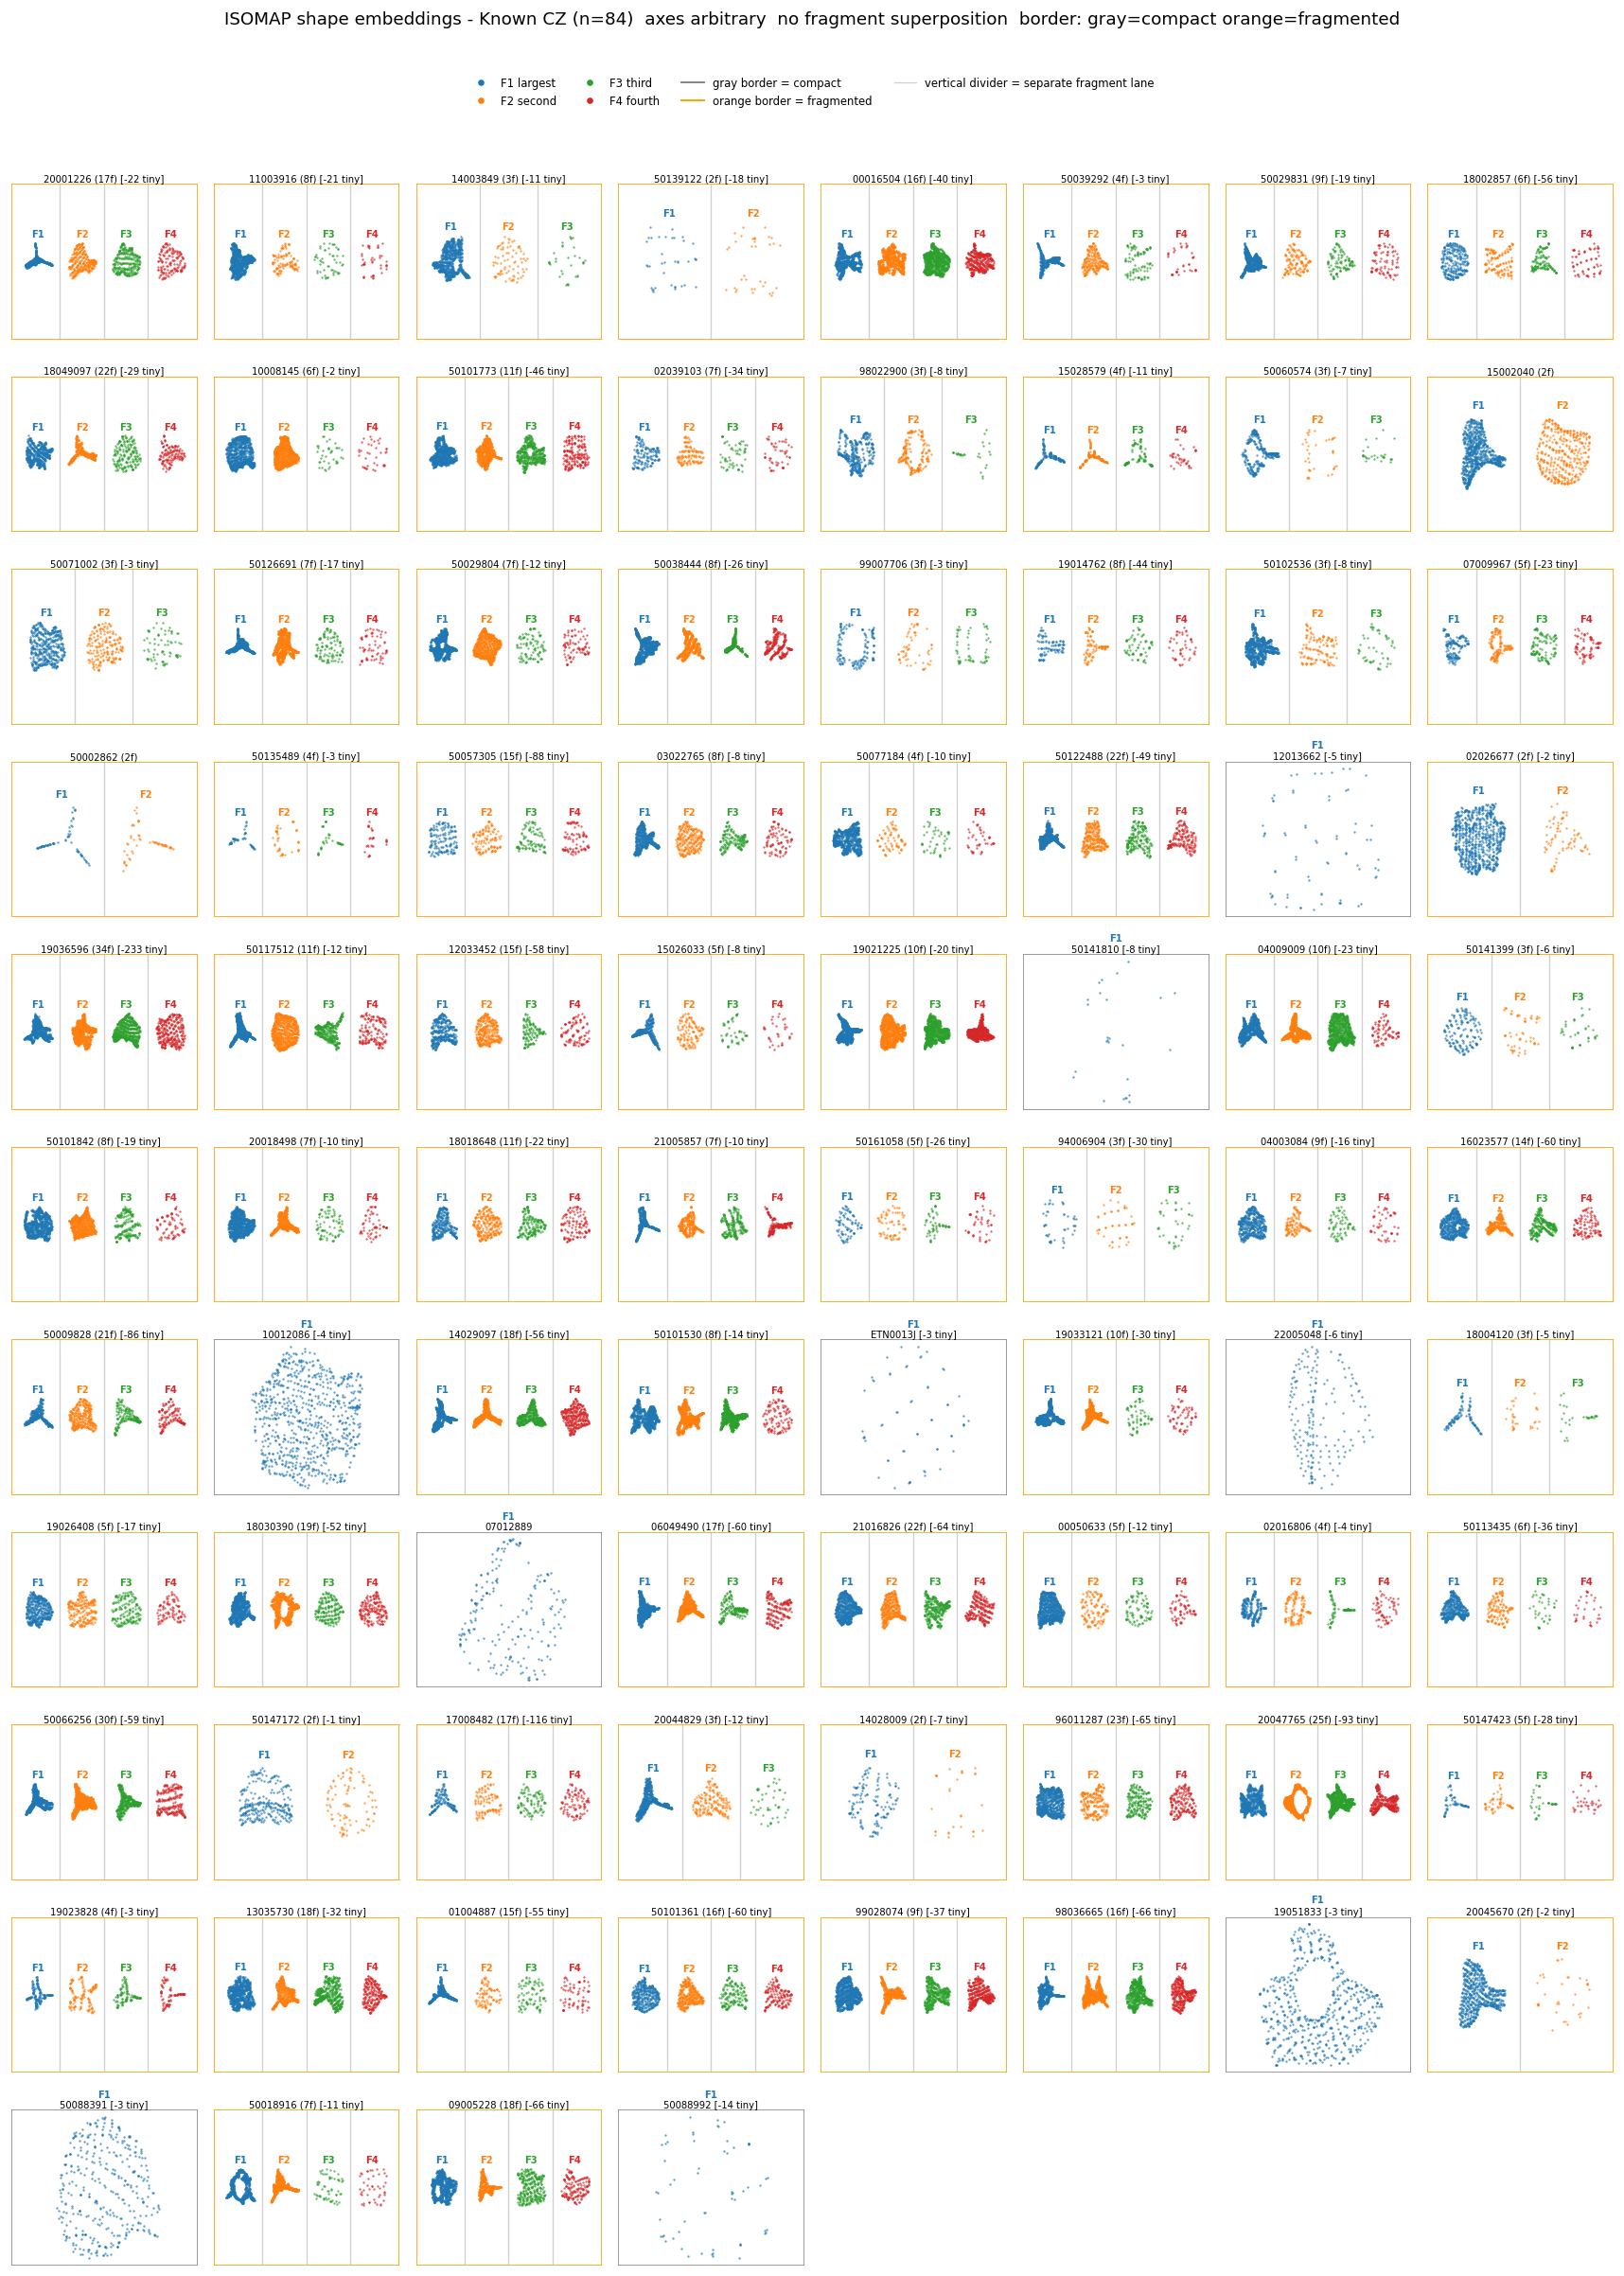

In [19]:
FRAG_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
LANE_HALF_WIDTH = 0.32
LANE_HALF_HEIGHT = 0.42

def _fit_embedding_to_lane(emb, x_center, half_width=LANE_HALF_WIDTH, half_height=LANE_HALF_HEIGHT):
    emb = np.asarray(emb, dtype=float)
    emb = emb - emb.mean(axis=0, keepdims=True)
    maxabs_x = np.max(np.abs(emb[:, 0])) if len(emb) else 1.0
    maxabs_y = np.max(np.abs(emb[:, 1])) if len(emb) else 1.0
    sx = half_width / max(maxabs_x, 1e-9)
    sy = half_height / max(maxabs_y, 1e-9)
    emb2 = emb.copy()
    emb2[:, 0] = emb2[:, 0] * sx + x_center
    emb2[:, 1] = emb2[:, 1] * sy
    return emb2

def _plot_isomap_cell(ax, analysis):
    shown = min(len(analysis.embeddings), MAX_PLOT_FRAGMENTS)
    if shown == 0:
        ax.text(0.5, 0.5, "no emb", ha="center", va="center", fontsize=6, transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        return
    centers = [0.0] if shown == 1 else np.linspace(-(shown - 1) / 2, (shown - 1) / 2, shown)
    for fi, (emb, count, xoff) in enumerate(zip(analysis.embeddings[:shown], analysis.vertex_counts[:shown], centers)):
        color = FRAG_COLORS[fi % len(FRAG_COLORS)]
        if emb is not None and len(emb) > 0:
            emb_lane = _fit_embedding_to_lane(emb, xoff)
            ax.scatter(emb_lane[:, 0], emb_lane[:, 1], s=2, c=[color], alpha=0.7, linewidths=0)
            ax.text(xoff, 0.52, f"F{fi+1}", color=color, fontsize=6, fontweight='bold',
                    ha="center", va="bottom",
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.2))
        else:
            ax.scatter([xoff], [0], marker="x", s=20, c=[color], linewidths=1)
            ax.text(xoff, 0.52, f"F{fi+1}", color=color, fontsize=6, fontweight='bold',
                    ha="center", va="bottom",
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.2))
    if shown > 1:
        mids = (centers[:-1] + centers[1:]) / 2
        for mid in mids:
            ax.axvline(mid, color="#d0d0d0", lw=0.8, zorder=0)
    n   = analysis.n_fragments
    pid = analysis.key.split("/")[1]
    suffix = f" ({n}f)" if n > 1 else ""
    if analysis.dropped_fragments > 0:
        suffix += f" [-{analysis.dropped_fragments} tiny]"
    ax.set_title(f"{pid}{suffix}", fontsize=6, pad=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(min(centers) - 0.6, max(centers) + 0.6)
    # set_ylim removed: with adjustable="datalim" it was ignored anyway (caused a matplotlib warning)
    try:
        ax.set_aspect("equal", adjustable="datalim")
    except Exception:
        pass
    bc = "orange" if not analysis.is_compact else "#888888"
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color(bc)


if not analyses:
    print("No analyses available - check scan.")
else:
    ikeys = list(analyses.keys())
    ncols = 8
    nrows = max(1, int(np.ceil(len(ikeys) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.8, nrows*1.8), squeeze=False)
    fig.suptitle(
        f"ISOMAP shape embeddings - Known CZ (n={len(ikeys)})  axes arbitrary  no fragment superposition  border: gray=compact orange=fragmented",
        fontsize=11, y=1.01
    )
    axes_flat = axes.ravel()
    for ax in axes_flat:
        ax.axis("off")
    for ax, key in zip(axes_flat, ikeys):
        ax.axis("on")
        try:
            _plot_isomap_cell(ax, analyses[key])
        except Exception as e:
            ax.set_title(key.split("/")[1], fontsize=6)
            print(f"  plot failed {key}: {e}")
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[0], markersize=5, label='F1 largest'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[1], markersize=5, label='F2 second'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[2], markersize=5, label='F3 third'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[3], markersize=5, label='F4 fourth'),
        plt.Line2D([0], [0], color='#888888', lw=1.2, label='gray border = compact'),
        plt.Line2D([0], [0], color='orange', lw=1.2, label='orange border = fragmented'),
        plt.Line2D([0], [0], color='#d0d0d0', lw=0.8, label='vertical divider = separate fragment lane'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.985),
               ncol=4, fontsize=7, frameon=False)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.savefig(OUT / "isomap_grid_known.png", bbox_inches="tight")
    plt.show()


### 5c - 3D fragment vs Isomap diagnostic

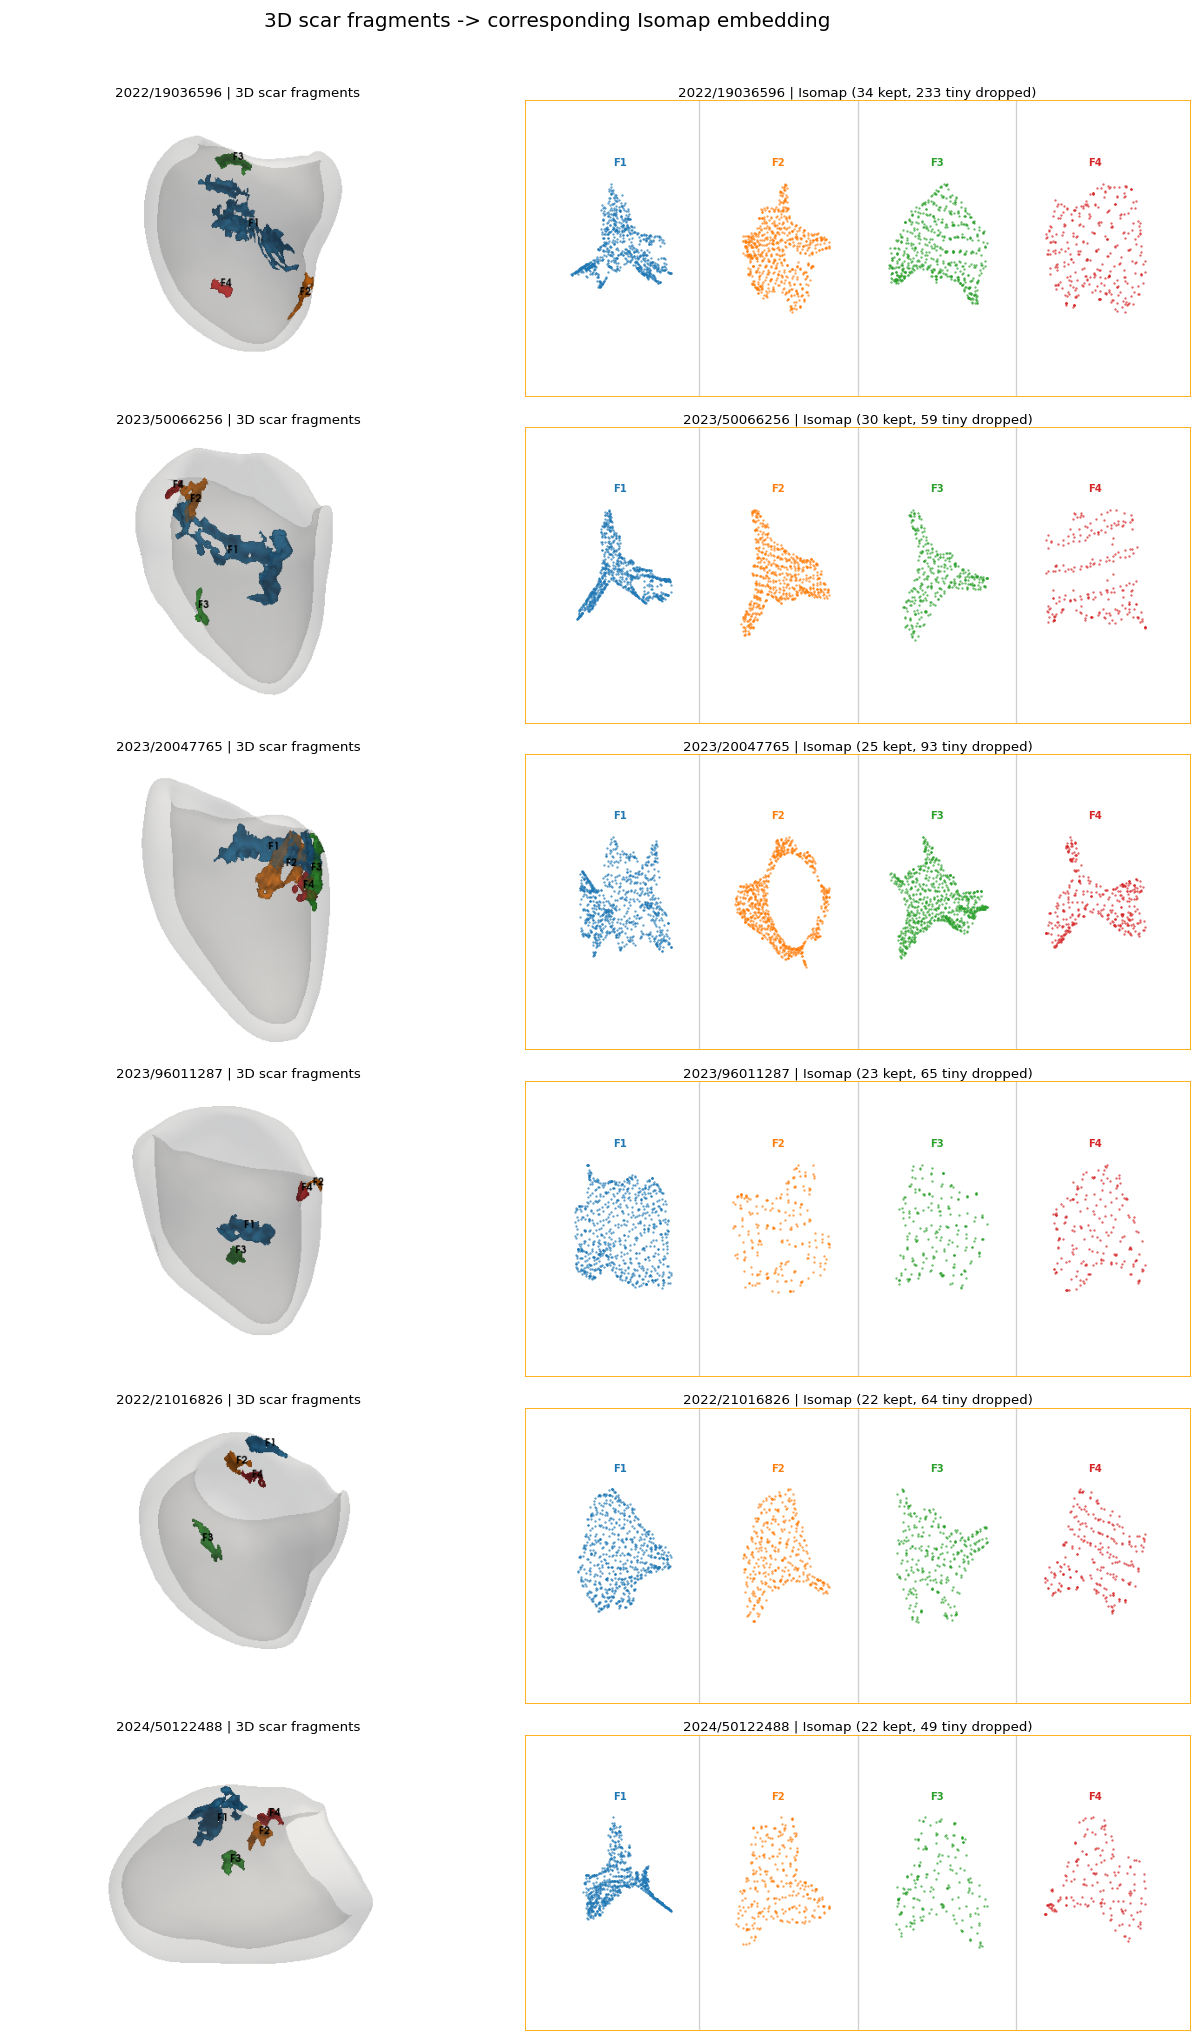

In [20]:
ISOMAP_DIAG_CASES = 6

def _render_fragments_3d(analysis, case=None, title=''):
    shown = min(len(analysis.fragment_meshes), MAX_PLOT_FRAGMENTS)
    pl = pv.Plotter(off_screen=True, window_size=(520, 340))
    pl.set_background('white')
    if case is not None:
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='#cccccc', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
    for fi, frag in enumerate(analysis.fragment_meshes[:shown]):
        color = FRAG_COLORS[fi % len(FRAG_COLORS)]
        pl.add_mesh(frag, color=color, smooth_shading=True, opacity=0.95, show_scalar_bar=False)
        center = np.asarray(frag.center)
        pl.add_point_labels([center], [f'F{fi+1}'], font_size=12, point_size=0,
                            text_color='black', shape_opacity=0.0, always_visible=True)
    pl.view_isometric()
    pl.camera.zoom(1.25)
    img = pl.screenshot(None, return_img=True)
    pl.close()
    return img

def _plot_isomap_large(ax, analysis):
    _plot_isomap_cell(ax, analysis)
    ax.set_title(ax.get_title(), fontsize=8, pad=2)

if not analyses:
    print('No analyses available - run section 5a first.')
else:
    diag_cases = sorted(
        analyses.values(),
        key=lambda a: (a.n_fragments, a.dropped_fragments, sum(a.vertex_counts)),
        reverse=True,
    )[:ISOMAP_DIAG_CASES]
    nrows = len(diag_cases)
    fig, axes = plt.subplots(nrows, 2, figsize=(11, max(3, nrows * 2.8)))
    if nrows == 1:
        axes = np.array([axes])
    fig.suptitle('3D scar fragments -> corresponding Isomap embedding', fontsize=12, y=1.01)
    for row, analysis in enumerate(diag_cases):
        ax3d, axiso = axes[row]
        year, pid = analysis.key.split('/')
        case = next((c for c in known if c.patient_id == pid and str(c.year) == year), None)
        img = _render_fragments_3d(analysis, case=case, title=analysis.key)
        ax3d.imshow(img)
        ax3d.axis('off')
        ax3d.set_title(f"{analysis.key} | 3D scar fragments", fontsize=8, pad=2)
        _plot_isomap_large(axiso, analysis)
        axiso.set_title(
            f"{analysis.key} | Isomap ({analysis.n_fragments} kept, {analysis.dropped_fragments} tiny dropped)",
            fontsize=8,
            pad=2,
        )
    plt.tight_layout()
    plt.savefig(OUT / 'isomap_3d_vs_embedding_diagnostic.png', bbox_inches='tight')
    plt.show()


### 5d - Fragmentation summary

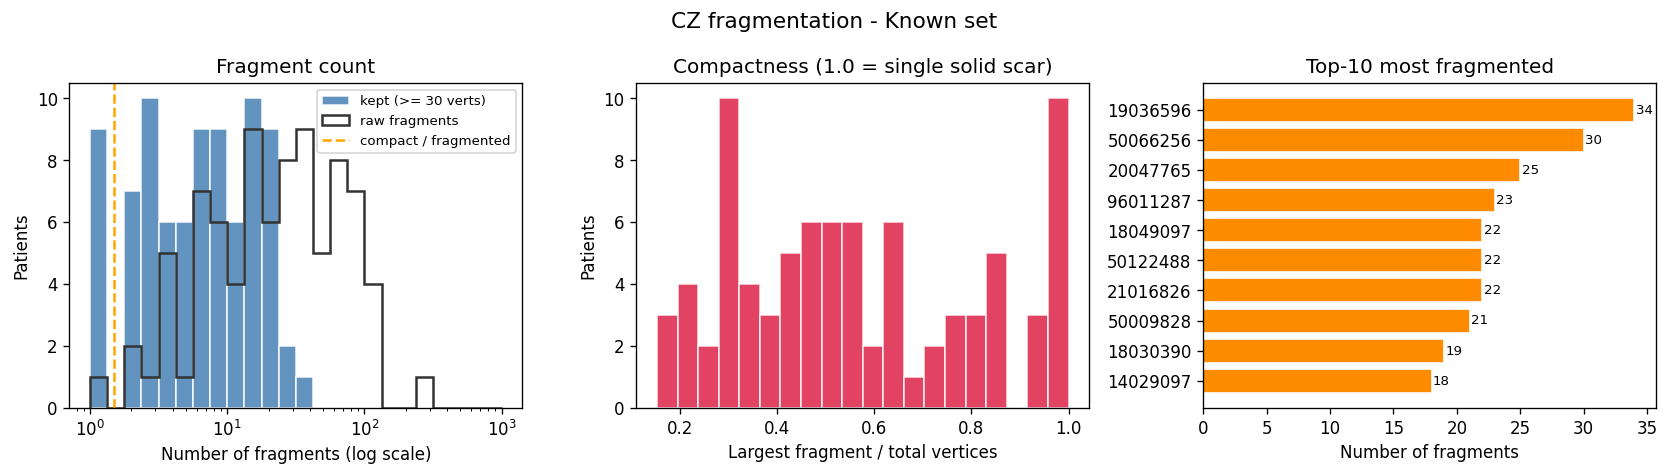

Median raw fragments         : 23
Median kept fragments        : 7
Max kept fragments           : 34
Median tiny fragments dropped: 17
Compact patients             : 9


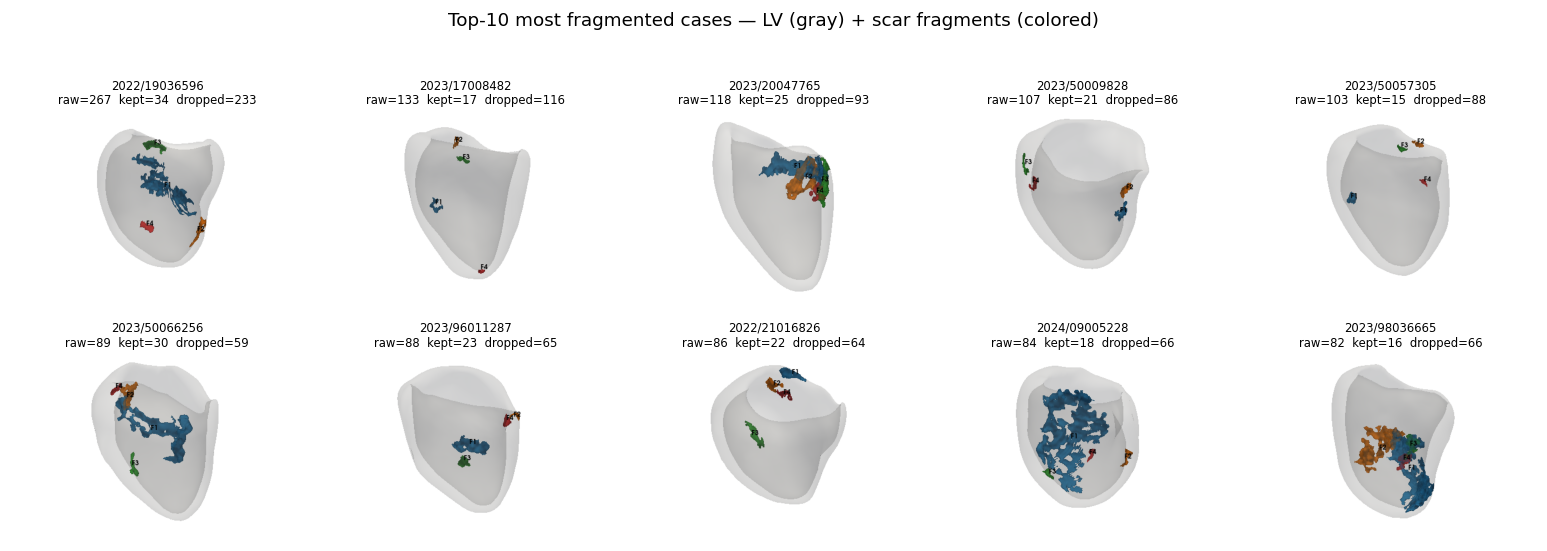

In [21]:
if not analyses:
    print("No analyses.")
else:
    n_frags_all      = [a.n_fragments       for a in analyses.values()]
    raw_n_frags_all  = [a.raw_n_fragments   for a in analyses.values()]
    dropped_all      = [a.dropped_fragments for a in analyses.values()]
    largest_frac_all = [a.largest_fraction  for a in analyses.values()]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("CZ fragmentation - Known set", fontsize=13)

    # --- Fragment count ---
    ax = axes[0]
    log_bins = np.logspace(0, np.ceil(np.log10(max(raw_n_frags_all) + 1)), 25)
    # kept: solid fill; raw: step outline so it never covers kept bars
    ax.hist(n_frags_all, bins=log_bins, color="steelblue", edgecolor="white",
            alpha=0.85, label=f"kept (>= {MIN_VERTS_FRAGMENT} verts)")
    ax.hist(raw_n_frags_all, bins=log_bins, histtype="step",
            color="#333333", linewidth=1.5, label="raw fragments")
    ax.set_xscale("log")
    ax.axvline(1.5, color="orange", lw=1.5, ls="--", label="compact / fragmented")
    ax.set_xlabel("Number of fragments (log scale)")
    ax.set_ylabel("Patients")
    ax.set_title("Fragment count")
    ax.legend(fontsize=8)

    # --- Compactness ---
    ax = axes[1]
    ax.hist(largest_frac_all, bins=20, color="crimson", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Largest fragment / total vertices")
    ax.set_ylabel("Patients")
    ax.set_title("Compactness (1.0 = single solid scar)")

    # --- Top-10 bar chart ---
    ax = axes[2]
    top10  = sorted(analyses.values(), key=lambda a: a.n_fragments, reverse=True)[:10]
    labels = [a.key.split("/")[1] for a in top10]
    counts = [a.n_fragments for a in top10]
    bars   = ax.barh(labels[::-1], counts[::-1], color="darkorange", edgecolor="white")
    ax.set_xlabel("Number of fragments")
    ax.set_title("Top-10 most fragmented")
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT / "fragmentation_summary.png", bbox_inches="tight")
    plt.show()

    print(f"Median raw fragments         : {int(np.median(raw_n_frags_all))}")
    print(f"Median kept fragments        : {int(np.median(n_frags_all))}")
    print(f"Max kept fragments           : {max(n_frags_all)}")
    print(f"Median tiny fragments dropped: {int(np.median(dropped_all))}")
    print(f"Compact patients             : {sum(1 for n in n_frags_all if n == 1)}")

    # --- 3D render grid: top fragmented cases ---
    TOP_FRAG_SHOW = 10
    top_frags = sorted(analyses.values(), key=lambda a: a.raw_n_fragments, reverse=True)[:TOP_FRAG_SHOW]
    ncols_g = 5
    nrows_g = int(np.ceil(TOP_FRAG_SHOW / ncols_g))
    fig2, axes2 = plt.subplots(nrows_g, ncols_g,
                               figsize=(ncols_g * 2.6, nrows_g * 2.4),
                               squeeze=False)
    fig2.suptitle(f"Top-{TOP_FRAG_SHOW} most fragmented cases — LV (gray) + scar fragments (colored)",
                  fontsize=11, y=1.01)
    for idx, analysis in enumerate(top_frags):
        ax = axes2[idx // ncols_g][idx % ncols_g]
        year, pid = analysis.key.split('/')
        case = next((c for c in known if c.patient_id == pid and str(c.year) == year), None)
        try:
            img = _render_fragments_3d(analysis, case=case)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha='center', va='center',
                    fontsize=6, transform=ax.transAxes, wrap=True)
        ax.axis('off')
        ax.set_title(
            f"{analysis.key}\n"
            f"raw={analysis.raw_n_fragments}  kept={analysis.n_fragments}  dropped={analysis.dropped_fragments}",
            fontsize=7, pad=2)
    for idx in range(TOP_FRAG_SHOW, nrows_g * ncols_g):
        axes2[idx // ncols_g][idx % ncols_g].axis('off')
    plt.tight_layout()
    plt.savefig(OUT / "top_fragmented_3d.png", bbox_inches="tight")
    plt.show()


XYZ-shape candidates (auto): 19


,key,year,patient_id,raw_n_fragments,n_fragments_kept,dropped_tiny,largest_fraction,f1_vertices,f1_peak_angles_deg,f1_arm_spacings_deg,selection_source
0,2021/15002040,2021,15002040,2,2,0,0.750,1242,"[132.5, 227.5, 357.5]","[95.0, 130.0, 135.0]",auto
1,2021/18018648,2021,18018648,33,11,22,0.255,334,"[77.5, 222.5, 337.5]","[145.0, 115.0, 100.0]",auto
2,2021/19033121,2021,19033121,40,10,30,0.711,2660,"[82.5, 192.5, 347.5]","[110.0, 155.0, 95.0]",auto
3,2021/20045670,2021,20045670,4,2,2,0.949,668,"[137.5, 212.5, 352.5]","[75.0, 140.0, 145.0]",auto
4,2022/11003916,2022,11003916,29,8,21,0.764,1144,"[7.5, 127.5, 242.5]","[120.0, 115.0, 125.0]",auto
5,2022/19036596,2022,19036596,267,34,233,0.474,3688,"[117.5, 197.5, 357.5]","[80.0, 160.0, 120.0]",auto
6,2022/50018916,2022,50018916,18,7,11,0.511,2252,"[87.5, 192.5, 337.5]","[105.0, 145.0, 110.0]",auto
7,2022/50029831,2022,50029831,28,9,19,0.852,3132,"[132.5, 217.5, 347.5]","[85.0, 130.0, 145.0]",auto
8,2022/50038444,2022,50038444,34,8,26,0.507,1578,"[2.5, 137.5, 227.5]","[135.0, 90.0, 135.0]",auto
9,2023/00050633,2023,00050633,17,5,12,0.689,772,"[132.5, 212.5, 347.5]","[80.0, 135.0, 145.0]",auto


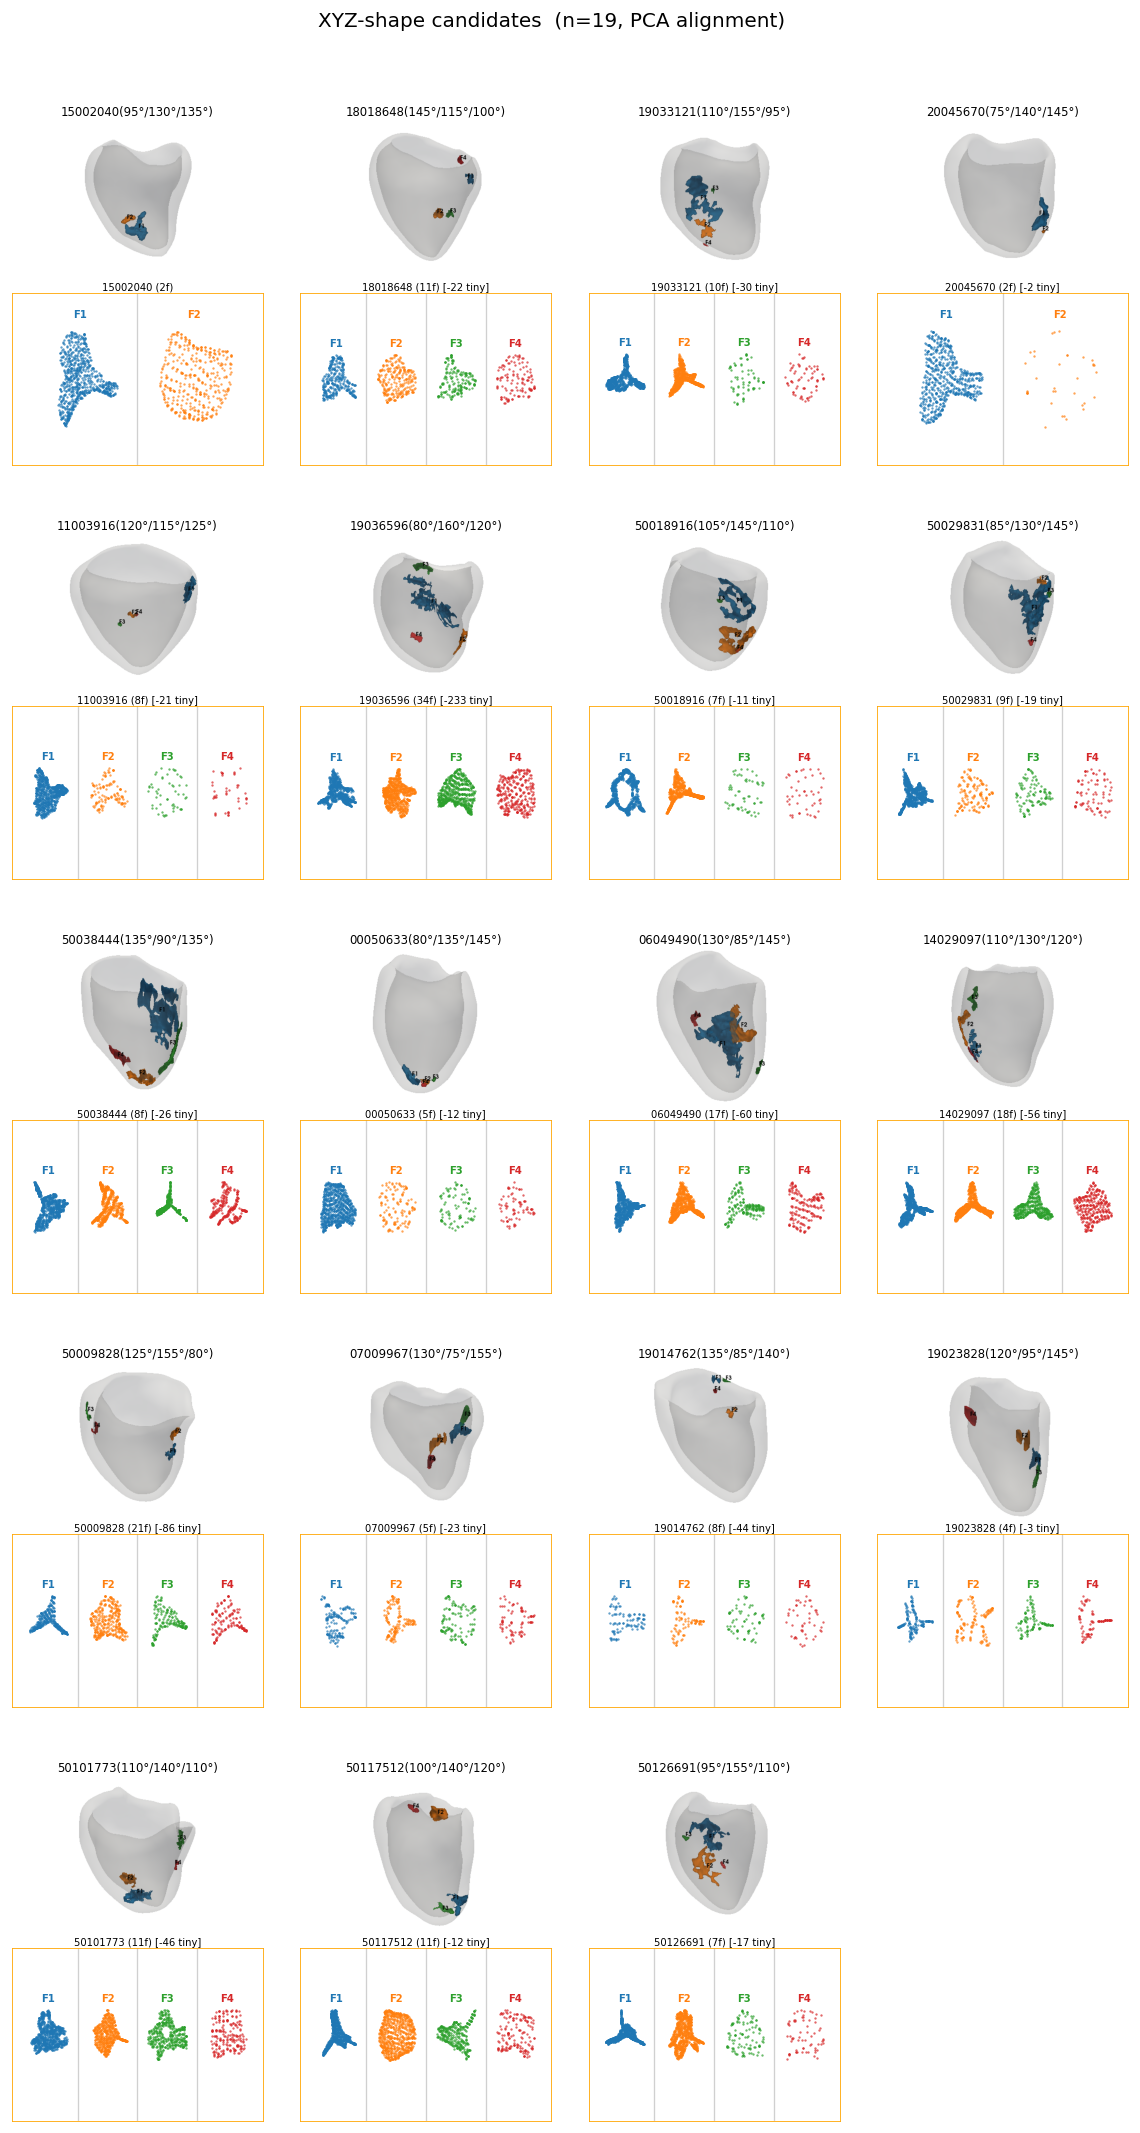

In [23]:
XYZ_SHAPE_KEYS = [
    # Optional manual override after visual review, e.g.:
    # '2024/12345678',
]

XYZ_N_BINS        = 72
XYZ_SMOOTH_BINS   = 5
XYZ_MIN_PEAK_PROM = 0.07   # was 0.10 – lower to catch shallower arms
XYZ_MIN_PEAK_RADIUS = 0.30  # was 0.45 – accept more modest arm extent
XYZ_ARM_SPACING_DEG = 120
XYZ_ARM_TOL_DEG   = 45    # was 35 – allow more variation in arm spacing

def _f1_xyz_signature(analysis, n_bins=XYZ_N_BINS):
    emb = analysis.embeddings[0] if analysis.embeddings else None
    if emb is None or len(emb) < 30:
        return None
    pts = np.asarray(emb, dtype=float)
    pts = pts - pts.mean(axis=0, keepdims=True)
    radii  = np.linalg.norm(pts, axis=1)
    angles = np.arctan2(pts[:, 1], pts[:, 0])
    bins   = np.linspace(-np.pi, np.pi, n_bins + 1)
    mids   = 0.5 * (bins[:-1] + bins[1:])
    idx    = np.clip(np.digitize(angles, bins) - 1, 0, n_bins - 1)

    radial_env = np.zeros(n_bins, dtype=float)
    for bi, ri in zip(idx, radii):
        radial_env[bi] = max(radial_env[bi], ri)

    smooth_env = uniform_filter1d(radial_env, size=XYZ_SMOOTH_BINS, mode='wrap')
    peaks, props = find_peaks(
        smooth_env,
        prominence=XYZ_MIN_PEAK_PROM,
        distance=max(4, n_bins // 6),
    )
    peak_angles = (np.degrees(mids[peaks]) + 360) % 360
    peak_radii  = smooth_env[peaks]
    keep = peak_radii >= XYZ_MIN_PEAK_RADIUS
    peak_angles = np.sort(peak_angles[keep])
    peak_radii  = peak_radii[keep]

    is_xyz = False
    arm_spacings = np.array([])
    if len(peak_angles) == 3:
        arm_spacings = np.diff(np.r_[peak_angles, peak_angles[0] + 360])
        is_xyz = np.all(np.abs(arm_spacings - XYZ_ARM_SPACING_DEG) <= XYZ_ARM_TOL_DEG)

    return {
        'is_xyz': bool(is_xyz),
        'n_peaks': int(len(peak_angles)),
        'peak_angles_deg': np.round(peak_angles, 1).tolist(),
        'peak_radii': np.round(peak_radii, 3).tolist(),
        'arm_spacings_deg': np.round(arm_spacings, 1).tolist(),
    }


xyz_auto_rows = []
for analysis in analyses.values():
    sig = _f1_xyz_signature(analysis)
    if sig is None or not sig['is_xyz']:
        continue
    year, pid = analysis.key.split('/')
    xyz_auto_rows.append({
        'key': analysis.key,
        'year': int(year),
        'patient_id': pid,
        'raw_n_fragments': analysis.raw_n_fragments,
        'n_fragments_kept': analysis.n_fragments,
        'dropped_tiny': analysis.dropped_fragments,
        'largest_fraction': round(float(analysis.largest_fraction), 3),
        'f1_vertices': int(analysis.vertex_counts[0]) if analysis.vertex_counts else 0,
        'f1_peak_angles_deg': sig['peak_angles_deg'],
        'f1_arm_spacings_deg': sig['arm_spacings_deg'],
        'selection_source': 'auto',
    })

xyz_auto_df = pd.DataFrame(xyz_auto_rows).sort_values(
    ['year', 'patient_id']
).reset_index(drop=True) if xyz_auto_rows else pd.DataFrame()

if XYZ_SHAPE_KEYS:
    xyz_selected_df = pd.DataFrame([
        row for row in xyz_auto_rows if row['key'] in XYZ_SHAPE_KEYS
    ]).sort_values(['year', 'patient_id']).reset_index(drop=True)
    missing_keys = [k for k in XYZ_SHAPE_KEYS if k not in set(xyz_selected_df.get('key', []))]
    if missing_keys:
        print('Manual keys not matched by current auto-heuristic:')
        for key in missing_keys:
            print('  ', key)
else:
    xyz_selected_df = xyz_auto_df.copy()

print(f"XYZ-shape candidates (auto): {len(xyz_auto_df)}")
display(xyz_selected_df)

# --- Grid view of XYZ candidates (report-friendly) ---
# Each cell: 3D render on top, ISOMAP embedding below
xyz_keys = list(xyz_selected_df['key']) if not xyz_selected_df.empty else []
if not xyz_keys:
    print("No XYZ candidates to plot.")
else:
    XYZ_NCOLS = 4
    nrows_xyz = int(np.ceil(len(xyz_keys) / XYZ_NCOLS))
    fig_xyz = plt.figure(figsize=(XYZ_NCOLS * 3.0, nrows_xyz * 3.8))
    fig_xyz.suptitle(
        f"XYZ-shape candidates  (n={len(xyz_keys)}, PCA alignment)",
        fontsize=12, y=0.975,
    )
    outer = fig_xyz.add_gridspec(
        nrows_xyz, XYZ_NCOLS,
        top=0.93, bottom=0.05,
        hspace=0.18, wspace=0.15,
    )
    for idx, key in enumerate(xyz_keys):
        row_o, col_o = divmod(idx, XYZ_NCOLS)
        inner = outer[row_o, col_o].subgridspec(2, 1, hspace=0.03, height_ratios=[1.0, 1.0])
        ax3d  = fig_xyz.add_subplot(inner[0])
        axiso = fig_xyz.add_subplot(inner[1])

        analysis = analyses[key]
        year, pid = key.split('/')
        case = next((c for c in known if c.patient_id == pid and str(c.year) == year), None)

        try:
            img = _render_fragments_3d(analysis, case=case)
            ax3d.imshow(img)
        except Exception as e:
            ax3d.text(0.5, 0.5, str(e), ha='center', va='center',
                      fontsize=6, transform=ax3d.transAxes, wrap=True)
        ax3d.axis('off')
        sig = _f1_xyz_signature(analysis)
        spacings_str = "/".join(f"{s:.0f}°" for s in sig['arm_spacings_deg']) if sig else "?"
        ax3d.set_title(f"{pid}({spacings_str})", fontsize=7, pad=2)

        try:
            _plot_isomap_cell(axiso, analysis)
        except Exception as e:
            axiso.text(0.5, 0.5, str(e), ha='center', va='center',
                       fontsize=6, transform=axiso.transAxes)
            axiso.axis('off')

    for idx in range(len(xyz_keys), nrows_xyz * XYZ_NCOLS):
        row_o, col_o = divmod(idx, XYZ_NCOLS)
        fig_xyz.add_subplot(outer[row_o, col_o]).axis('off')

    plt.savefig(OUT / "xyz_candidates.png", bbox_inches="tight")
    plt.show()

---
## Outputs

| File | Content |
|---|---|
| results/split.json | Frozen Known/Held-out lists |
| results/3d_overlay_known.png | Aligned CZ overlay |
| results/3d_grid_known.png | Per-patient 3-D thumbnails |
| results/polar_grid_known.png | Individual bull's-eye maps |
| results/polar_superposition_known.png | Population scar density |
| results/isomap_grid_known.png | Per-scar ISOMAP embeddings |
| results/fragmentation_summary.png | Fragment distribution |